In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_test.csv" 
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.02_acc0.025_test.csv" 

# low pass filter for inputs
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_eevel0.3_eeacc0.1_test.csv" 
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_eevel0.4_eeacc0.2_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_eevel0.5_eeacc0.4_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_vel0.0_acc0.0_eevel0.7_eeacc0.4_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_emavel0.3_emaacc0.1_velstd0.002_accstd0.05_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_emavel0.3_emaacc0.1_velstd0.001_accstd0.05_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_emavel0.3_emaacc0.1_velstd0.00075_accstd0.05_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_emavel0.3_emaacc0.1_velstd0.0005_accstd0.05_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel0.3_velstd0.0005_test.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0.csv"

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# 2. LOAD DATA
# ==========================================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
    print("Please check the path and try again.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded data!")
    print(f"   Rows (Envs): {df.shape[0]}")
    print(f"   Columns:     {df.shape[1]}")
    print(f"Columns found: {list(df.columns)[:10]} ... and {len(df.columns)-10} more")

    # Display the dataframe
    # display(df)

✅ Successfully loaded data!
   Rows (Envs): 40960
   Columns:     4929
Columns found: ['env_id', 'seed', 'range_type', 'start_t', 'end_t', 'gt_mass', 'gt_mu', 'gt_fric_force', 'cube_size', 'raw_ee_acc_t0_ax0'] ... and 4919 more


In [2]:
# --- FIX DATA TYPES ---
# The 'gt_fric_force' column was saved as strings (e.g., "[4.23]"). 
# We need to strip brackets and convert to float.
def clean_force_col(x):
    if isinstance(x, str):
        # Remove '[' and ']' and convert to float
        return float(x.strip('[]'))
    return x

if 'gt_fric_force' in df.columns:
    df['gt_fric_force'] = df['gt_fric_force'].apply(clean_force_col)
    print("✅ Fixed 'gt_fric_force' column types.")

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_sequence_data(row, prefix, seq_len=100, num_axes=6):
    """Reconstructs (100, 6) array from flattened columns like 'prefix_t0_ax0'"""
    data = np.zeros((seq_len, num_axes))
    for t in range(seq_len):
        for ax in range(num_axes):
            col = f"{prefix}_t{t}_ax{ax}"
            if col in row:
                data[t, ax] = row[col]
    return data

def get_flat_window(row, prefix, window_size=10):
    """Reconstructs 1D array from columns like 'prefix_0', 'prefix_1'"""
    data = np.zeros(window_size)
    for i in range(window_size):
        col = f"{prefix}_{i}"
        if col in row:
            data[i] = row[col]
    return data

✅ Fixed 'gt_fric_force' column types.



ANALYZING SAMPLE #3619
GT Mass: 2.360 kg
GT Mu:   0.423
GT Fric Force (Target): 9.107 N
Time Window: 20 -> 80


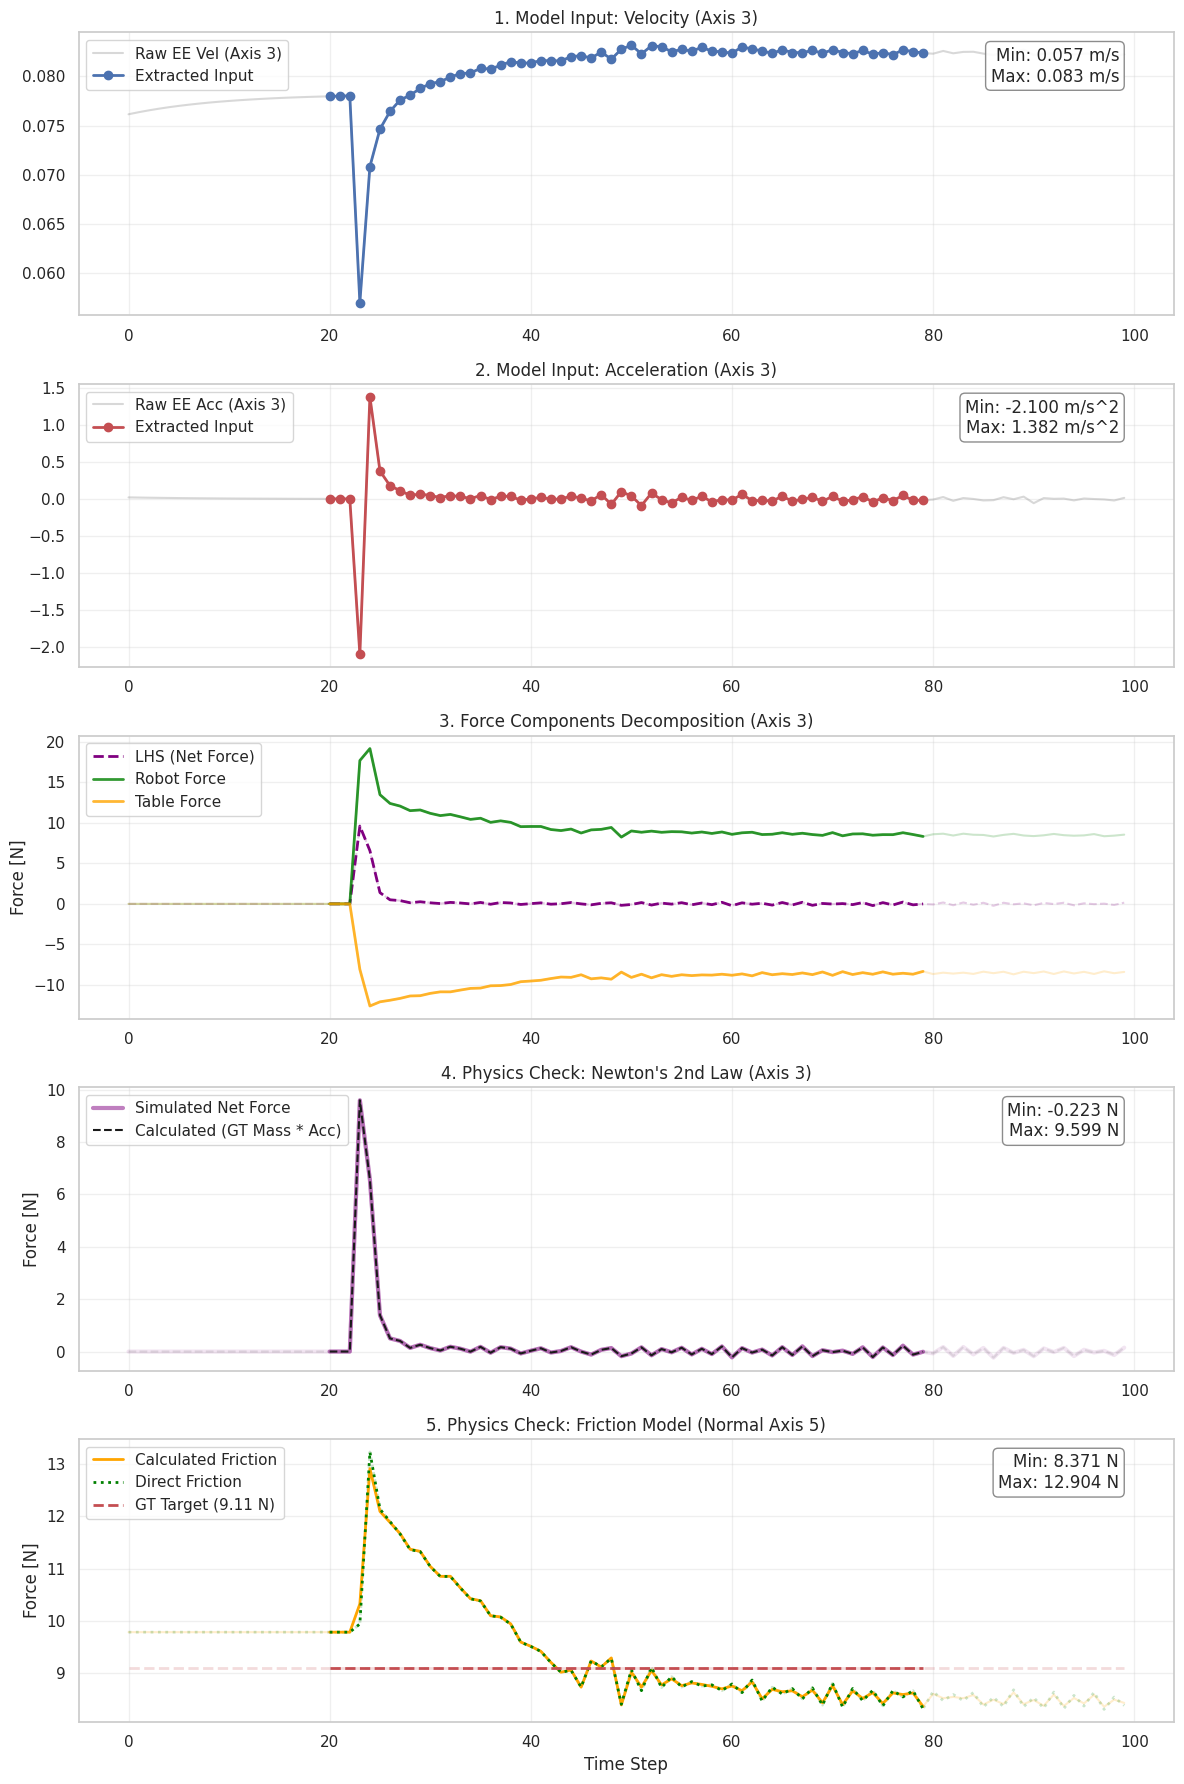

In [3]:
# ==========================================
# 5. INTEGRATED SAMPLE ANALYSIS (UPDATED WITH HIGHLIGHTS + MIN/MAX)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81

    # 1. Pick a single random sample for ALL plots
    sample_idx = np.random.randint(0, len(df))
    row = df.iloc[sample_idx]
    
    print(f"\n=======================================================")
    print(f"ANALYZING SAMPLE #{sample_idx}")
    print(f"=======================================================")
    print(f"GT Mass: {row['gt_mass']:.3f} kg")
    print(f"GT Mu:   {row['gt_mu']:.3f}")
    
    gt_fric_force_val = row['gt_fric_force']
    if isinstance(gt_fric_force_val, str):
        gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
    print(f"GT Fric Force (Target): {gt_fric_force_val:.3f} N")
    print(f"Time Window: {int(row['start_t'])} -> {int(row['end_t'])}")

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # --- 2. EXTRACT DATA ---
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")      
    rhs_acc = get_sequence_data(row, "pinn_RHS_acc")            
    robot_wrench = get_sequence_data(row, "pinn_robot_wrench")  
    table_wrench = get_sequence_data(row, "pinn_table_wrench")  
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)

    # --- 3. CALCULATIONS ---
    # Newton Check
    net_force_sim = lhs_wrench[:, AXIS_MOTION]
    acc_sim = rhs_acc[:, AXIS_MOTION]
    net_force_calc = row['gt_mass'] * acc_sim

    # Friction Check
    robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
    normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
    fric_force_calc_profile = row['gt_mu'] * normal_force_calc
    
    normal_force_direct = table_wrench[:, AXIS_VERTICAL]
    fric_force_direct_profile = row['gt_mu'] * normal_force_direct
    
    fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

    # --- 4. PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    
    # Plot 1: Velocity Input
    axes[0].plot(raw_vel[:, AXIS_MOTION], label=f'Raw EE Vel (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[0].plot(time_steps, input_vel, 'b-o', linewidth=2, label='Extracted Input')
    
    axes[0].set_title(f"1. Model Input: Velocity (Axis {AXIS_MOTION})")
    add_min_max_text(axes[0], input_vel, "m/s") # Add stats
    axes[0].legend(loc='upper left')

    # Plot 2: Acceleration Input
    axes[1].plot(raw_acc[:, AXIS_MOTION], label=f'Raw EE Acc (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[1].plot(time_steps, input_acc, 'r-o', linewidth=2, label='Extracted Input')
    
    axes[1].set_title(f"2. Model Input: Acceleration (Axis {AXIS_MOTION})")
    add_min_max_text(axes[1], input_acc, "m/s^2") # Add stats
    axes[1].legend(loc='upper left')

    # Plot 3: Component Breakdown
    lhs_val = lhs_wrench[:, AXIS_MOTION]
    robot_val = robot_wrench[:, AXIS_MOTION]
    table_val = table_wrench[:, AXIS_MOTION]
    
    # Background
    axes[2].plot(lhs_val, color='purple', linestyle='--', alpha=0.2)
    axes[2].plot(robot_val, color='green', alpha=0.2)
    axes[2].plot(table_val, color='orange', alpha=0.2)
    
    # Foreground
    net_win = lhs_val[time_steps]
    axes[2].plot(time_steps, net_win, label='LHS (Net Force)', color='purple', linestyle='--', linewidth=2)
    axes[2].plot(time_steps, robot_val[time_steps], label='Robot Force', color='green', alpha=0.8, linewidth=2)
    axes[2].plot(time_steps, table_val[time_steps], label='Table Force', color='orange', alpha=0.8, linewidth=2)
    
    axes[2].set_title(f"3. Force Components Decomposition (Axis {AXIS_MOTION})")
    axes[2].set_ylabel("Force [N]")
    axes[2].legend(loc='upper left')

    # Plot 4: Newton's Law Check
    # Background
    axes[3].plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
    axes[3].plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
    
    # Foreground
    sim_win = net_force_sim[time_steps]
    axes[3].plot(time_steps, sim_win, label='Simulated Net Force', color='purple', linewidth=3, alpha=0.5)
    axes[3].plot(time_steps, net_force_calc[time_steps], 'k--', label='Calculated (GT Mass * Acc)', linewidth=1.5)
    
    axes[3].set_title(f"4. Physics Check: Newton's 2nd Law (Axis {AXIS_MOTION})")
    axes[3].set_ylabel("Force [N]")
    add_min_max_text(axes[3], sim_win, "N") # Add stats for Sim Force
    axes[3].legend(loc='upper left')

    # Plot 5: Friction Model Check
    # Background
    axes[4].plot(fric_force_calc_profile, color='orange', alpha=0.2)
    axes[4].plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
    axes[4].plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)

    # Foreground
    calc_win = fric_force_calc_profile[time_steps]
    axes[4].plot(time_steps, calc_win, label='Calculated Friction', color='orange', linewidth=2)
    axes[4].plot(time_steps, fric_force_direct_profile[time_steps], label='Direct Friction', color='green', linestyle=':', linewidth=2)
    axes[4].plot(time_steps, fric_force_gt_line[time_steps], 'r--', label=f'GT Target ({gt_fric_force_val:.2f} N)', linewidth=2)
    
    axes[4].set_title(f"5. Physics Check: Friction Model (Normal Axis {AXIS_VERTICAL})")
    axes[4].set_ylabel("Force [N]")
    axes[4].set_xlabel("Time Step")
    add_min_max_text(axes[4], calc_win, "N") # Add stats for Calculated Friction
    axes[4].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


✅ Selected Simulation Sample #37766
   Target: Mass 0.390, Mu 0.300


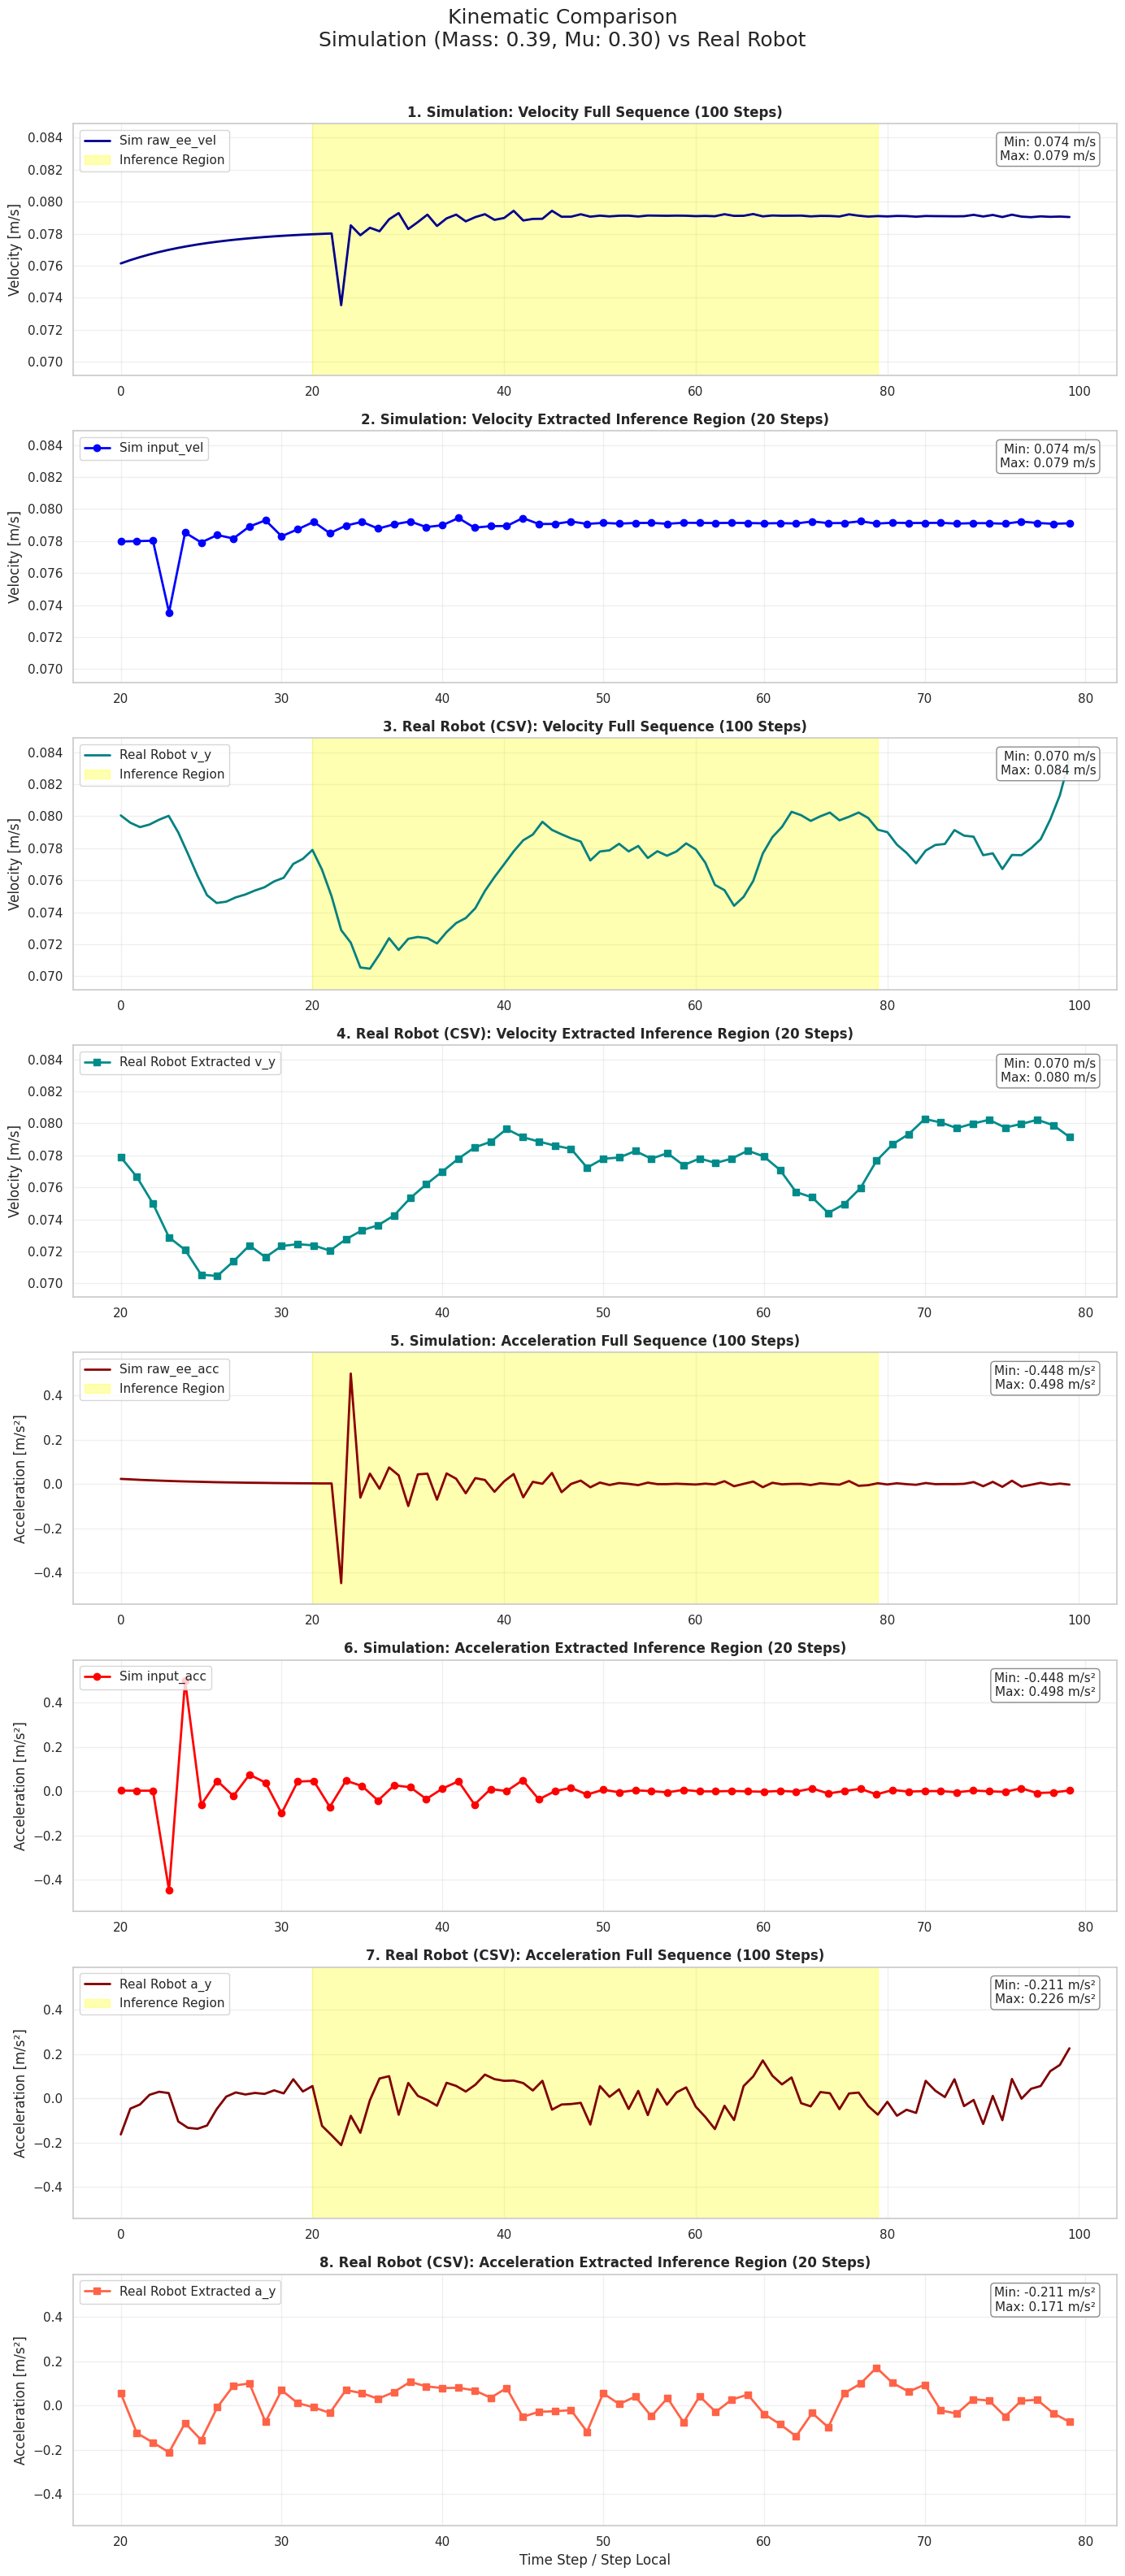

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.39      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction
AXIS_MOTION = 3         # Assuming axis 3 is your motion axis
csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv"

# =================================================================
# 1. FIND CLOSEST SIMULATION SAMPLE
# =================================================================
if 'df' in locals():
    # Calculate Euclidean distance to the target properties
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
    # Get the single closest sample
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    m_val = row['gt_mass']
    mu_val = row['gt_mu']
    print(f"\n✅ Selected Simulation Sample #{closest_idx}")
    print(f"   Target: Mass {target_mass:.3f}, Mu {target_mu:.3f}")

    # Extract Simulation Data
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    
    # Clean up
    df.drop(columns=['dist'], inplace=True)
else:
    print("❌ Error: 'df' not found. Please run the data loading cell first.")
    raise ValueError("Missing Simulation DataFrame.")

# =================================================================
# 2. LOAD CSV DATA (Real Robot)
# =================================================================
if os.path.exists(csv_path):
    data_test = pd.read_csv(csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    a_csv = data_test['a_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
        a_ext = a_csv[inf_indices]
    else:
        steps_ext, v_ext, a_ext = [], [], []
else:
    print(f"❌ File not found: {csv_path}")
    data_test = None
    v_csv, a_csv = [0], [0]

# =================================================================
# 3. CALCULATE SHARED SCALES (GLOBAL LIMITS)
# =================================================================
sim_v_full = raw_vel[:, AXIS_MOTION]
sim_a_full = raw_acc[:, AXIS_MOTION]

v_min = min(np.min(sim_v_full), np.min(v_csv))
v_max = max(np.max(sim_v_full), np.max(v_csv))
v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
shared_v_lim = (v_min - v_pad, v_max + v_pad)

a_min = min(np.min(sim_a_full), np.min(a_csv))
a_max = max(np.max(sim_a_full), np.max(a_csv))
a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
shared_a_lim = (a_min - a_pad, a_max + a_pad)

# Helper for stats
def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 4. UNIFIED VISUALIZATION (8 Subplots)
# =================================================================
fig, axes = plt.subplots(8, 1, figsize=(14, 32))
fig.suptitle(f"Kinematic Comparison\nSimulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f}) vs Real Robot", fontsize=18, y=0.99)
raw_vel[:, AXIS_MOTION]
# ----------------- VELOCITY -----------------
# 1. SIMULATION: Velocity (100 Steps)
axes[0].plot(np.arange(len(raw_vel)), sim_v_full, color='darkblue', linewidth=2, label='Sim raw_ee_vel')
axes[0].set_title("1. Simulation: Velocity Full Sequence (100 Steps)", fontweight='bold')
axes[0].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[0], sim_v_full, "m/s")
axes[0].axvspan(time_steps[0], time_steps[-1], color='yellow', alpha=0.3, label='Inference Region')
axes[0].set_ylim(shared_v_lim)
axes[0].legend(loc='upper left')

# 2. SIMULATION: Velocity (20 Steps)
axes[1].plot(time_steps, input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
axes[1].set_title("2. Simulation: Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
axes[1].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[1], input_vel, "m/s")
axes[1].set_ylim(shared_v_lim)
axes[1].legend(loc='upper left')

if data_test is not None:
    # 3. REAL ROBOT: Velocity (100 Steps)
    axes[2].plot(steps_csv, v_csv, color='teal', linewidth=2, label='Real Robot v_y')
    axes[2].set_title("3. Real Robot (CSV): Velocity Full Sequence (100 Steps)", fontweight='bold')
    axes[2].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[2], v_csv, "m/s")
    if len(inf_indices) > 0:
        axes[2].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
    axes[2].set_ylim(shared_v_lim)
    axes[2].legend(loc='upper left')

    # 4. REAL ROBOT: Velocity (20 Steps)
    if len(inf_indices) > 0:
        axes[3].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
        axes[3].set_title("4. Real Robot (CSV): Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
        axes[3].set_ylabel("Velocity [m/s]")
        add_min_max_text(axes[3], v_ext, "m/s")
        axes[3].set_ylim(shared_v_lim)
        axes[3].legend(loc='upper left')

# ----------------- ACCELERATION -----------------
# 5. SIMULATION: Acceleration (100 Steps)
axes[4].plot(np.arange(len(raw_acc)), sim_a_full, color='darkred', linewidth=2, label='Sim raw_ee_acc')
axes[4].set_title("5. Simulation: Acceleration Full Sequence (100 Steps)", fontweight='bold')
axes[4].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[4], sim_a_full, "m/s²")
axes[4].axvspan(time_steps[0], time_steps[-1], color='yellow', alpha=0.3, label='Inference Region')
axes[4].set_ylim(shared_a_lim)
axes[4].legend(loc='upper left')

# 6. SIMULATION: Acceleration (20 Steps)
axes[5].plot(time_steps, input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc')
axes[5].set_title("6. Simulation: Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
axes[5].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[5], input_acc, "m/s²")
axes[5].set_ylim(shared_a_lim)
axes[5].legend(loc='upper left')

if data_test is not None:
    # 7. REAL ROBOT: Acceleration (100 Steps)
    axes[6].plot(steps_csv, a_csv, color='maroon', linewidth=2, label='Real Robot a_y')
    axes[6].set_title("7. Real Robot (CSV): Acceleration Full Sequence (100 Steps)", fontweight='bold')
    axes[6].set_ylabel("Acceleration [m/s²]")
    add_min_max_text(axes[6], a_csv, "m/s²")
    if len(inf_indices) > 0:
        axes[6].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
    axes[6].set_ylim(shared_a_lim)
    axes[6].legend(loc='upper left')

    # 8. REAL ROBOT: Acceleration (20 Steps)
    if len(inf_indices) > 0:
        axes[7].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
        axes[7].set_title("8. Real Robot (CSV): Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
        axes[7].set_ylabel("Acceleration [m/s²]")
        axes[7].set_xlabel("Time Step / Step Local")
        add_min_max_text(axes[7], a_ext, "m/s²")
        axes[7].set_ylim(shared_a_lim)
        axes[7].legend(loc='upper left')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit the suptitle
plt.show()

In [5]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# # =================================================================
# # CONFIGURATION: Target Physics & Data Paths
# # =================================================================
# target_mass = 0.39      # Target GT Mass (kg)
# target_mu = 0.3         # Target GT Friction
# AXIS_MOTION = 3         # Assuming axis 3 is your motion axis
# # csv_path = "/home/psxkf4/panda_phypush/csv_data/infe_mest_0.216_muest_0.491_w5.csv"
# csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.76/infe_mest_0.290_muest_0.473_w5.csv"

# # =================================================================
# # 1. FIND CLOSEST SIMULATION SAMPLE
# # =================================================================
# if 'df' in locals():
#     # Calculate Euclidean distance to the target properties
#     df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
#     # Get the single closest sample
#     closest_idx = df['dist'].idxmin()
#     row = df.loc[closest_idx]
    
#     m_val = row['gt_mass']
#     mu_val = row['gt_mu']
#     print(f"\n✅ Selected Simulation Sample #{closest_idx}")
#     print(f"   Target: Mass {target_mass:.3f}, Mu {target_mu:.3f}")

#     # Extract Simulation Data
#     raw_acc = get_sequence_data(row, "raw_ee_acc")
#     raw_vel = get_sequence_data(row, "raw_ee_vel")
    
#     input_cols = [c for c in df.columns if "input_acc_" in c]
#     win_len = len(input_cols)
#     input_acc = get_flat_window(row, "input_acc", win_len)
#     input_vel = get_flat_window(row, "input_vel", win_len)
    
#     start_t = int(row['start_t'])
#     time_steps = np.arange(start_t, start_t + win_len)
    
#     # Clean up
#     df.drop(columns=['dist'], inplace=True)
# else:
#     print("❌ Error: 'df' not found. Please run the data loading cell first.")
#     raise ValueError("Missing Simulation DataFrame.")

# # =================================================================
# # 2. LOAD CSV DATA (Real Robot)
# # =================================================================
# if os.path.exists(csv_path):
#     data_test = pd.read_csv(csv_path)
#     steps_csv = data_test['step_local'].values
#     v_csv = data_test['v_y'].values
#     a_csv = data_test['a_y'].values
#     is_inf = data_test['is_inference_region'].values
    
#     inf_indices = np.where(is_inf == 1)[0]
#     if len(inf_indices) > 0:
#         steps_ext = steps_csv[inf_indices]
#         v_ext = v_csv[inf_indices]
#         a_ext = a_csv[inf_indices]
#     else:
#         steps_ext, v_ext, a_ext = [], [], []
# else:
#     print(f"❌ File not found: {csv_path}")
#     data_test = None
#     v_csv, a_csv = [0], [0]

# # =================================================================
# # 3. CALCULATE SHARED SCALES (GLOBAL LIMITS)
# # =================================================================
# sim_v_full = raw_vel[:, AXIS_MOTION]
# sim_a_full = raw_acc[:, AXIS_MOTION]

# v_min = min(np.min(sim_v_full), np.min(v_csv))
# v_max = max(np.max(sim_v_full), np.max(v_csv))
# v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
# shared_v_lim = (v_min - v_pad, v_max + v_pad)

# a_min = min(np.min(sim_a_full), np.min(a_csv))
# a_max = max(np.max(sim_a_full), np.max(a_csv))
# a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
# shared_a_lim = (a_min - a_pad, a_max + a_pad)

# # Helper for stats
# def add_min_max_text(ax, data, unit=""):
#     if len(data) == 0: return
#     dmin, dmax = np.min(data), np.max(data)
#     stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
#     ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
#             horizontalalignment='right', verticalalignment='top', fontsize=11,
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# # =================================================================
# # 4. UNIFIED VISUALIZATION (6 Subplots)
# # =================================================================
# fig, axes = plt.subplots(6, 1, figsize=(14, 24))
# fig.suptitle(f"Kinematic Comparison\nSimulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f}) vs Real Robot", fontsize=18, y=0.99)

# # ----------------- VELOCITY -----------------

# # 1. SIMULATION: Velocity (100 Steps + Overlay 20 Steps)
# axes[0].plot(np.arange(len(raw_vel)), sim_v_full, color='gray', alpha=0.5, linewidth=2, label='Sim raw_ee_vel (100 steps)')
# axes[0].plot(time_steps, input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel (20 steps)')
# axes[0].set_title("1. Simulation: Velocity (Raw vs Extracted Input)", fontweight='bold')
# axes[0].set_ylabel("Velocity [m/s]")
# add_min_max_text(axes[0], sim_v_full, "m/s")
# axes[0].set_ylim(shared_v_lim)
# axes[0].legend(loc='upper left')

# if data_test is not None:
#     # 2. REAL ROBOT: Velocity (100 Steps)
#     axes[1].plot(steps_csv, v_csv, color='teal', linewidth=2, label='Real Robot v_y')
#     axes[1].set_title("2. Real Robot (CSV): Velocity Full Sequence (100 Steps)", fontweight='bold')
#     axes[1].set_ylabel("Velocity [m/s]")
#     add_min_max_text(axes[1], v_csv, "m/s")
#     if len(inf_indices) > 0:
#         axes[1].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
#     axes[1].set_ylim(shared_v_lim)
#     axes[1].legend(loc='upper left')

#     # 3. REAL ROBOT: Velocity (20 Steps)
#     if len(inf_indices) > 0:
#         axes[2].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
#         axes[2].set_title("3. Real Robot (CSV): Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
#         axes[2].set_ylabel("Velocity [m/s]")
#         add_min_max_text(axes[2], v_ext, "m/s")
#         axes[2].set_ylim(shared_v_lim)
#         axes[2].legend(loc='upper left')

# # ----------------- ACCELERATION -----------------

# # 4. SIMULATION: Acceleration (100 Steps + Overlay 20 Steps)
# axes[3].plot(np.arange(len(raw_acc)), sim_a_full, color='gray', alpha=0.5, linewidth=2, label='Sim raw_ee_acc (100 steps)')
# axes[3].plot(time_steps, input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc (20 steps)')
# axes[3].set_title("4. Simulation: Acceleration (Raw vs Extracted Input)", fontweight='bold')
# axes[3].set_ylabel("Acceleration [m/s²]")
# add_min_max_text(axes[3], sim_a_full, "m/s²")
# axes[3].set_ylim(shared_a_lim)
# axes[3].legend(loc='upper left')


# if data_test is not None:
#     # 5. REAL ROBOT: Acceleration (100 Steps)
#     axes[4].plot(steps_csv, a_csv, color='maroon', linewidth=2, label='Real Robot a_y')
#     axes[4].set_title("5. Real Robot (CSV): Acceleration Full Sequence (100 Steps)", fontweight='bold')
#     axes[4].set_ylabel("Acceleration [m/s²]")
#     add_min_max_text(axes[4], a_csv, "m/s²")
#     if len(inf_indices) > 0:
#         axes[4].axvspan(steps_csv[inf_indices[0]], steps_csv[inf_indices[-1]], color='yellow', alpha=0.3, label='Inference Region')
#     axes[4].set_ylim(shared_a_lim)
#     axes[4].legend(loc='upper left')

#     # 6. REAL ROBOT: Acceleration (20 Steps)
#     if len(inf_indices) > 0:
#         axes[5].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
#         axes[5].set_title("6. Real Robot (CSV): Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
#         axes[5].set_ylabel("Acceleration [m/s²]")
#         axes[5].set_xlabel("Time Step / Step Local")
#         add_min_max_text(axes[5], a_ext, "m/s²")
#         axes[5].set_ylim(shared_a_lim)
#         axes[5].legend(loc='upper left')

# for ax in axes:
#     ax.grid(True, alpha=0.3)

# plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit the suptitle
# plt.show()


✅ Selected Simulation Sample #37766
   Target: Mass 0.390, Mu 0.300


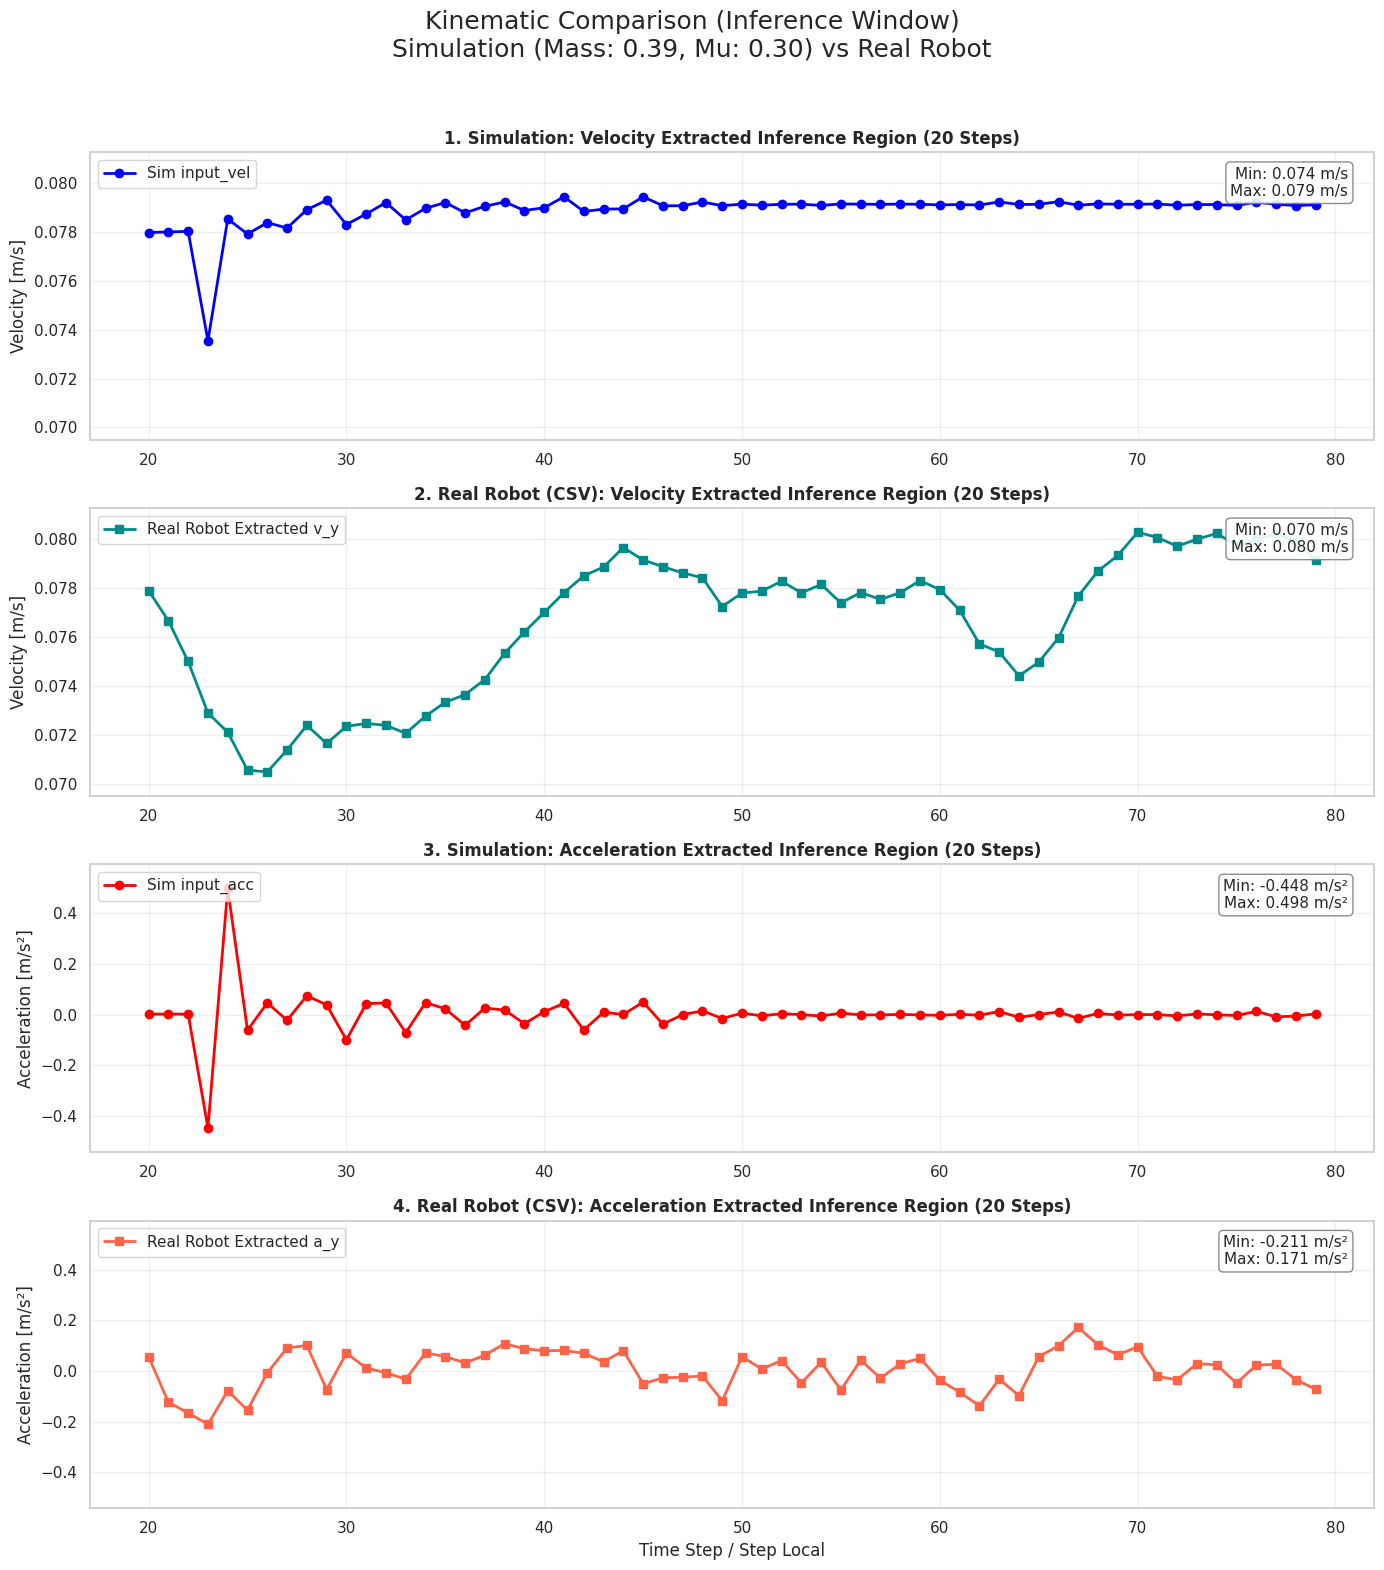

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.39      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction
AXIS_MOTION = 3         # Assuming axis 3 is your motion axis
csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv"

# =================================================================
# 1. FIND CLOSEST SIMULATION SAMPLE
# =================================================================
if 'df' in locals():
    # Calculate Euclidean distance to the target properties
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
    # Get the single closest sample
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    m_val = row['gt_mass']
    mu_val = row['gt_mu']
    print(f"\n✅ Selected Simulation Sample #{closest_idx}")
    print(f"   Target: Mass {target_mass:.3f}, Mu {target_mu:.3f}")

    # Extract Simulation Data
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    
    # Clean up
    df.drop(columns=['dist'], inplace=True)
else:
    print("❌ Error: 'df' not found. Please run the data loading cell first.")
    raise ValueError("Missing Simulation DataFrame.")

# =================================================================
# 2. LOAD CSV DATA (Real Robot)
# =================================================================
if os.path.exists(csv_path):
    data_test = pd.read_csv(csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    a_csv = data_test['a_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
        a_ext = a_csv[inf_indices]
    else:
        steps_ext, v_ext, a_ext = [], [], []
else:
    print(f"❌ File not found: {csv_path}")
    data_test = None
    v_ext, a_ext = [], []

# =================================================================
# 3. CALCULATE SHARED SCALES (BASED ON 20 STEPS ONLY)
# =================================================================
if len(v_ext) > 0:
    v_min = min(np.min(input_vel), np.min(v_ext))
    v_max = max(np.max(input_vel), np.max(v_ext))
    a_min = min(np.min(input_acc), np.min(a_ext))
    a_max = max(np.max(input_acc), np.max(a_ext))
else:
    v_min, v_max = np.min(input_vel), np.max(input_vel)
    a_min, a_max = np.min(input_acc), np.max(input_acc)

v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
shared_v_lim = (v_min - v_pad, v_max + v_pad)

a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
shared_a_lim = (a_min - a_pad, a_max + a_pad)

# Helper for stats
def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 4. UNIFIED VISUALIZATION (4 Subplots)
# =================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle(f"Kinematic Comparison (Inference Window)\nSimulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f}) vs Real Robot", fontsize=18, y=0.98)

# ----------------- VELOCITY -----------------

# 1. SIMULATION: Velocity (20 Steps)
axes[0].plot(time_steps, input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
axes[0].set_title("1. Simulation: Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
axes[0].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[0], input_vel, "m/s")
axes[0].set_ylim(shared_v_lim)
axes[0].legend(loc='upper left')

# 2. REAL ROBOT: Velocity (20 Steps)
if data_test is not None and len(inf_indices) > 0:
    axes[1].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
    axes[1].set_title("2. Real Robot (CSV): Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
    axes[1].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[1], v_ext, "m/s")
    axes[1].set_ylim(shared_v_lim)
    axes[1].legend(loc='upper left')
else:
    axes[1].set_title("2. Real Robot (CSV): Velocity Data Not Found", fontweight='bold')

# ----------------- ACCELERATION -----------------

# 3. SIMULATION: Acceleration (20 Steps)
axes[2].plot(time_steps, input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc')
axes[2].set_title("3. Simulation: Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
axes[2].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[2], input_acc, "m/s²")
axes[2].set_ylim(shared_a_lim)
axes[2].legend(loc='upper left')

# 4. REAL ROBOT: Acceleration (20 Steps)
if data_test is not None and len(inf_indices) > 0:
    axes[3].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
    axes[3].set_title("4. Real Robot (CSV): Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
    axes[3].set_ylabel("Acceleration [m/s²]")
    axes[3].set_xlabel("Time Step / Step Local")
    add_min_max_text(axes[3], a_ext, "m/s²")
    axes[3].set_ylim(shared_a_lim)
    axes[3].legend(loc='upper left')
else:
    axes[3].set_title("4. Real Robot (CSV): Acceleration Data Not Found", fontweight='bold')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to fit the suptitle
plt.show()

=== Starting Velocity Pattern Comparison Scan ===
Metric: Pearson Correlation -> HIGHER IS BETTER (1.0 = Perfect Shape Match)

File: data_tb-3_ta57_emavel0.0_velstd0.0005_test.csv
   -> Derivative Corr: -0.0065 | RMSE: 0.07737 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.1_velstd0.0005_test.csv
   -> Derivative Corr: -0.1034 | RMSE: 0.00285 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.2_velstd0.0005_test.csv
   -> Derivative Corr: 0.0669 | RMSE: 0.00332 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.3_velstd0.0005_test.csv
   -> Derivative Corr: 0.1344 | RMSE: 0.00321 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.4_velstd0.0005_test.csv
   -> Derivative Corr: 0.1722 | RMSE: 0.00310 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.5_velstd0.0005_test.csv
   -> Derivative Corr: 0.1991 | RMSE: 0.00304 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_ta57_emavel0.6_velstd0.0005_test.csv
   -> Derivative Corr: 0.2184 | RMSE: 0.00299 (Mass: 0.40, Mu: 0.32)
File: data_tb-3_t

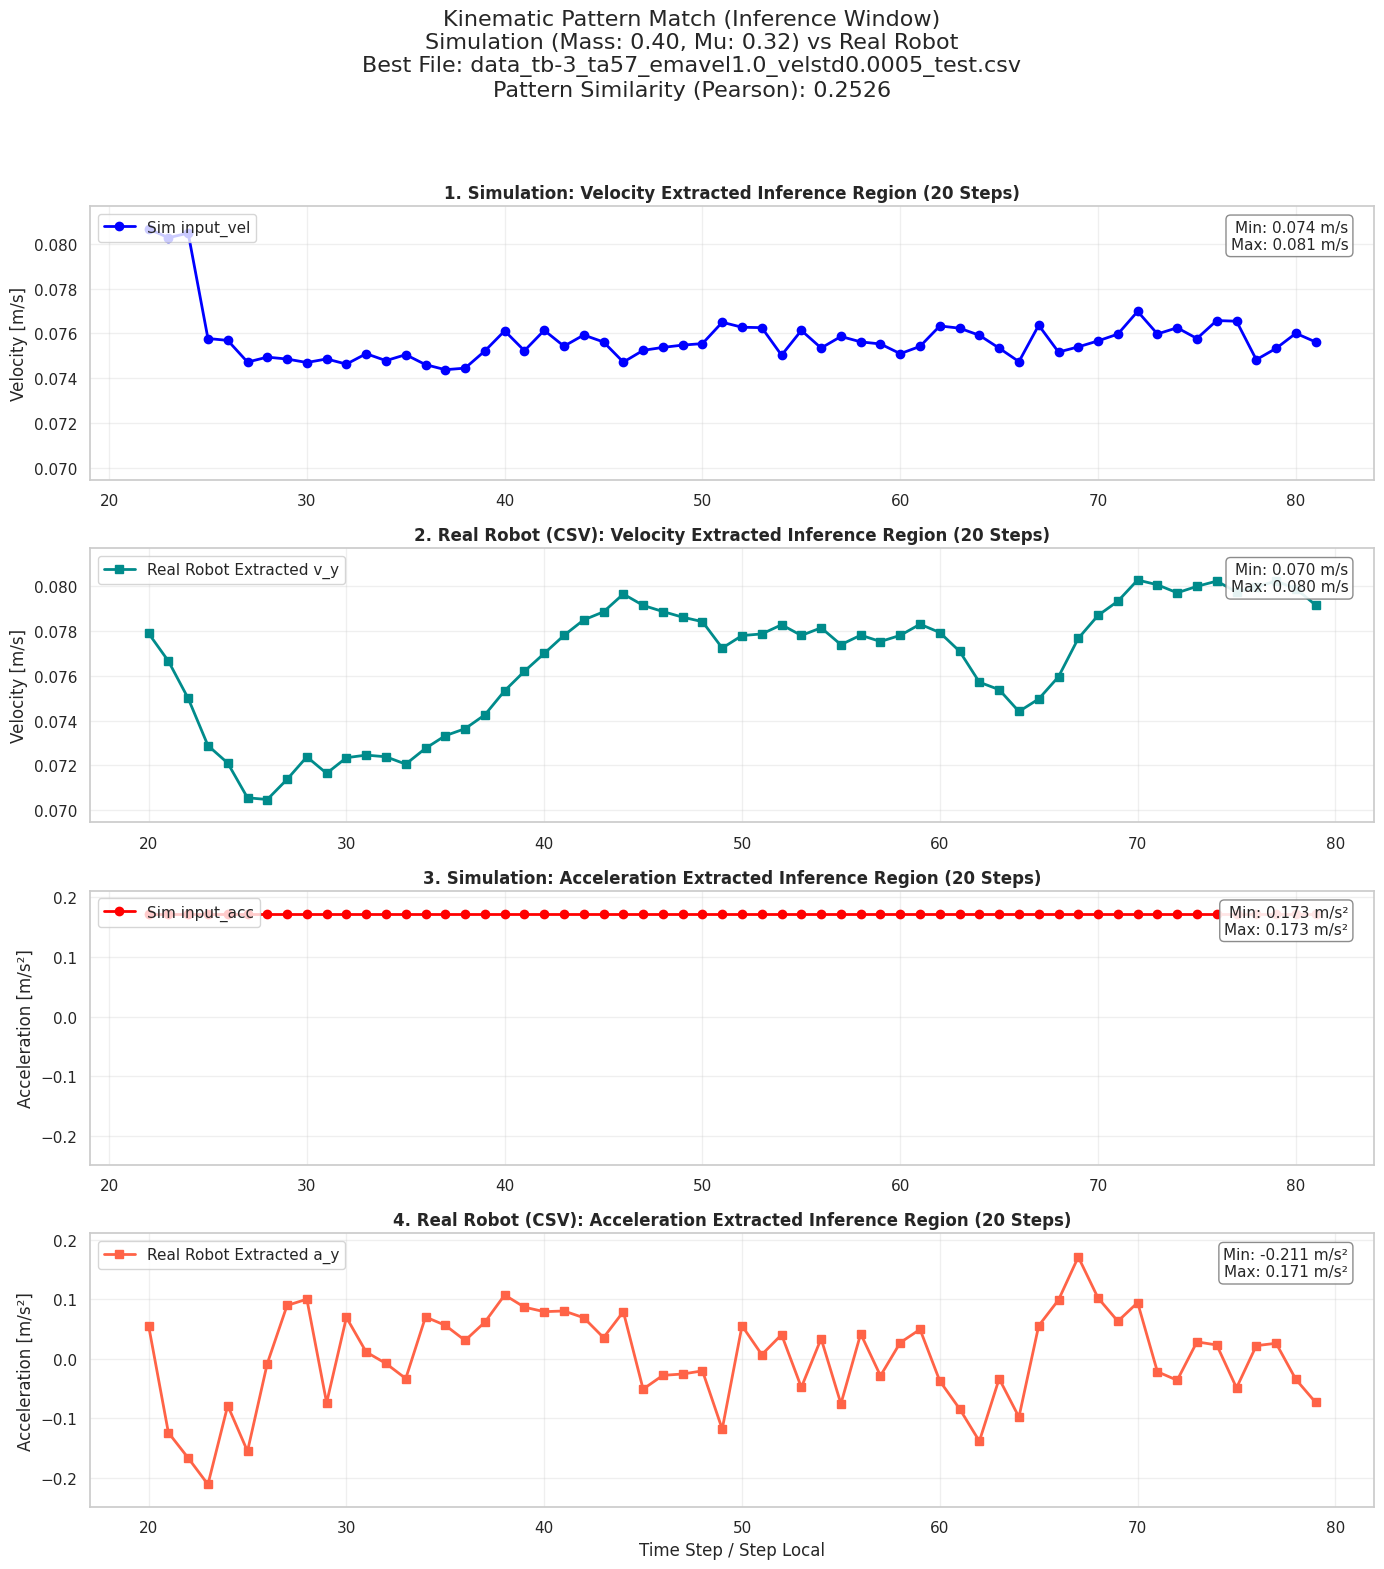

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.39      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction
AXIS_MOTION = 3         # Assuming axis 3 is your motion axis

# Path to the single real robot CSV you are comparing against
real_csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv"

# List all the simulation datasets you want to evaluate
base_dir = "/home/psxkf4/IsaacLab/source/collected_data/"

SIM_CSV_PATHS = [
    f"{base_dir}data_tb-3_ta57_emavel0.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.1_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.2_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.3_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.4_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.5_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.6_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.7_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.8_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.9_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0.csv",
]

# # Create a directory to save the best match plot
# save_dir = os.path.join(base_dir, "best_pattern_plots")
# os.makedirs(save_dir, exist_ok=True)

# Helper to extract the 20-step window
def get_flat_window(row, prefix, win_len):
    return np.array([row[f"{prefix}_{i}"] for i in range(win_len)])

# =================================================================
# 1. LOAD REAL ROBOT DATA (Target for comparison)
# =================================================================
if os.path.exists(real_csv_path):
    data_test = pd.read_csv(real_csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    a_csv = data_test['a_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
        a_ext = a_csv[inf_indices]
    else:
        steps_ext, v_ext, a_ext = [], [], []
else:
    print(f"❌ Error: Real robot file not found: {real_csv_path}")
    raise FileNotFoundError("Need real robot data to compare against.")

# =================================================================
# 2. ITERATE OVER SIMULATION DATASETS AND FIND BEST PATTERN MATCH
# =================================================================
best_corr = -float('inf')  # Higher is better for correlation (Max is 1.0)
best_sim_file = None
best_row = None
best_input_vel = None
best_input_acc = None

print("=== Starting Velocity Pattern Comparison Scan ===")
print("Metric: Pearson Correlation -> HIGHER IS BETTER (1.0 = Perfect Shape Match)\n")

for sim_path in SIM_CSV_PATHS:
    if not os.path.exists(sim_path):
        print(f"⚠️ Warning: File not found, skipping - {os.path.basename(sim_path)}")
        continue
        
    df = pd.read_csv(sim_path)
    
    # Calculate distance to target properties
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
    # Get the single closest sample in this specific CSV
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    # Extract Simulation Kinematics
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_vel = get_flat_window(row, "input_vel", win_len)
    

    # Calculate Pattern Similarity (Derivative Correlation)
    if len(input_vel) == len(v_ext):
        # 1. Calculate step-to-step changes (Derivative)
        sim_diff = np.diff(input_vel)
        real_diff = np.diff(v_ext)
        
        # 2. Correlate the changes (This forces it to match drops and spikes)
        corr_matrix = np.corrcoef(sim_diff + 1e-10, real_diff + 1e-10)
        shape_corr = corr_matrix[0, 1]
        
        if np.isnan(shape_corr): shape_corr = 0.0
        
        # Calculate standard RMSE just for logging/reference
        vel_rmse = np.sqrt(np.mean((input_vel - v_ext)**2))
        
        print(f"File: {os.path.basename(sim_path)}")
        print(f"   -> Derivative Corr: {shape_corr:.4f} | RMSE: {vel_rmse:.5f} (Mass: {row['gt_mass']:.2f}, Mu: {row['gt_mu']:.2f})")
        
        # We want the HIGHEST derivative correlation
        if shape_corr > best_corr:
            best_corr = shape_corr
            best_sim_file = sim_path
            best_row = row
            best_input_vel = input_vel
            best_input_acc = get_flat_window(row, "input_acc", win_len)
            
            # Save the RMSE of the best match just for the plot title
            best_rmse = vel_rmse 
    else:
        print(f"⚠️ Warning: Sequence length mismatch. Skipping {os.path.basename(sim_path)}")

# =================================================================
# 3. PREPARE BEST MATCH FOR PLOTTING
# =================================================================
if best_sim_file is None:
    raise ValueError("No valid simulation data found for comparison.")

print(f"\n🏆 BEST PATTERN MATCH: {os.path.basename(best_sim_file)}")
print(f"   Highest Shape Correlation: {best_corr:.4f}")

m_val = best_row['gt_mass']
mu_val = best_row['gt_mu']
start_t = int(best_row['start_t'])
time_steps = np.arange(start_t, start_t + len(best_input_vel))

# Calculate Shared Scales
v_min = min(np.min(best_input_vel), np.min(v_ext))
v_max = max(np.max(best_input_vel), np.max(v_ext))
a_min = min(np.min(best_input_acc), np.min(a_ext))
a_max = max(np.max(best_input_acc), np.max(a_ext))

v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
shared_v_lim = (v_min - v_pad, v_max + v_pad)

a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
shared_a_lim = (a_min - a_pad, a_max + a_pad)

def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 4. UNIFIED VISUALIZATION (4 Subplots) & SAVING
# =================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Title reflects the new pattern-matching logic
fig.suptitle(f"Kinematic Pattern Match (Inference Window)\nSimulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f}) vs Real Robot\nBest File: {os.path.basename(best_sim_file)}\nPattern Similarity (Pearson): {best_corr:.4f}", fontsize=16, y=0.98)

# ----------------- VELOCITY -----------------
axes[0].plot(time_steps, best_input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
axes[0].set_title("1. Simulation: Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
axes[0].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[0], best_input_vel, "m/s")
axes[0].set_ylim(shared_v_lim)
axes[0].legend(loc='upper left')

axes[1].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
axes[1].set_title(f"2. Real Robot (CSV): Velocity Extracted Inference Region (20 Steps)", fontweight='bold')
axes[1].set_ylabel("Velocity [m/s]")
add_min_max_text(axes[1], v_ext, "m/s")
axes[1].set_ylim(shared_v_lim)
axes[1].legend(loc='upper left')

# ----------------- ACCELERATION -----------------
axes[2].plot(time_steps, best_input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc')
axes[2].set_title("3. Simulation: Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
axes[2].set_ylabel("Acceleration [m/s²]")
add_min_max_text(axes[2], best_input_acc, "m/s²")
axes[2].set_ylim(shared_a_lim)
axes[2].legend(loc='upper left')

axes[3].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
axes[3].set_title("4. Real Robot (CSV): Acceleration Extracted Inference Region (20 Steps)", fontweight='bold')
axes[3].set_ylabel("Acceleration [m/s²]")
axes[3].set_xlabel("Time Step / Step Local")
add_min_max_text(axes[3], a_ext, "m/s²")
axes[3].set_ylim(shared_a_lim)
axes[3].legend(loc='upper left')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# # Save the figure automatically using Correlation in the filename
# filename_only = os.path.basename(best_sim_file).replace(".csv", f"_Corr_{best_corr:.3f}.png")
# save_path = os.path.join(save_dir, filename_only)
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
# print(f"✅ Saved Best Pattern Match figure to: {save_path}")

plt.show()

=== Pre-loading Simulation Datasets into Memory ===
✅ Successfully cached 12 simulation files.


[1/10] ANALYZING REAL DATA: ext_60steps_20260220-180352_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel0.7_velstd0.0005_test.csv
   Shape Correlation: 0.1217 | RMSE: 0.00591


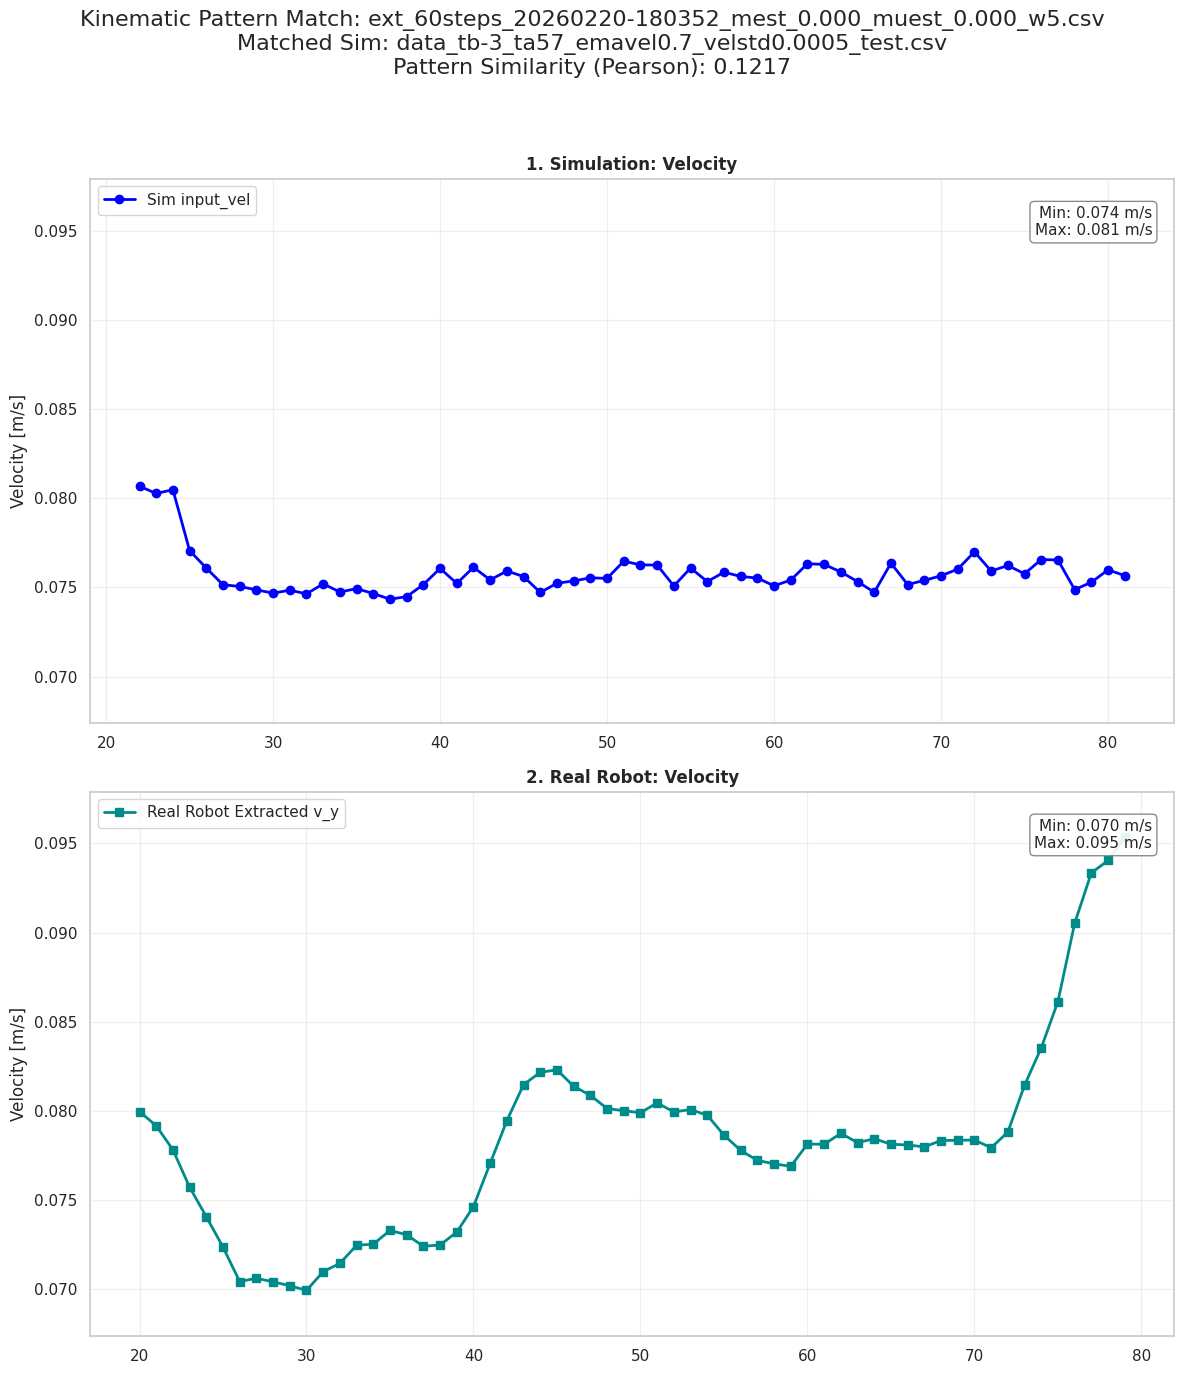


[2/10] ANALYZING REAL DATA: ext_60steps_20260220-180304_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel0.6_velstd0.0005_test.csv
   Shape Correlation: 0.3259 | RMSE: 0.00527


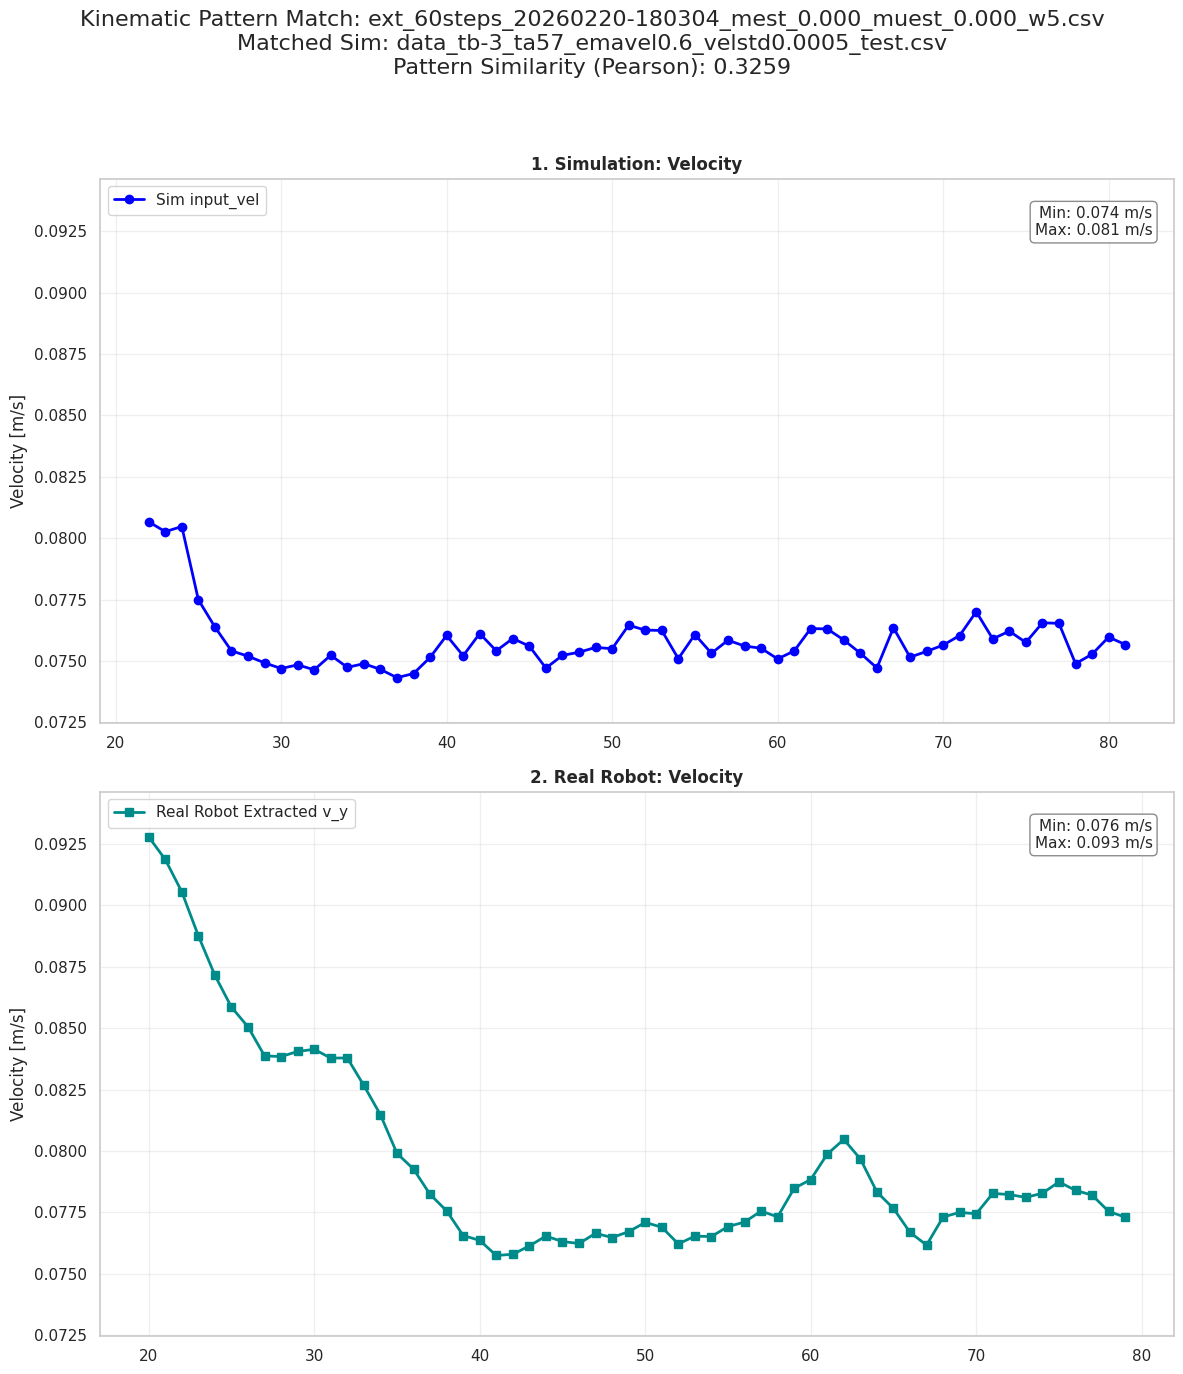


[3/10] ANALYZING REAL DATA: ext_60steps_20260220-180443_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.3648 | RMSE: 0.00295


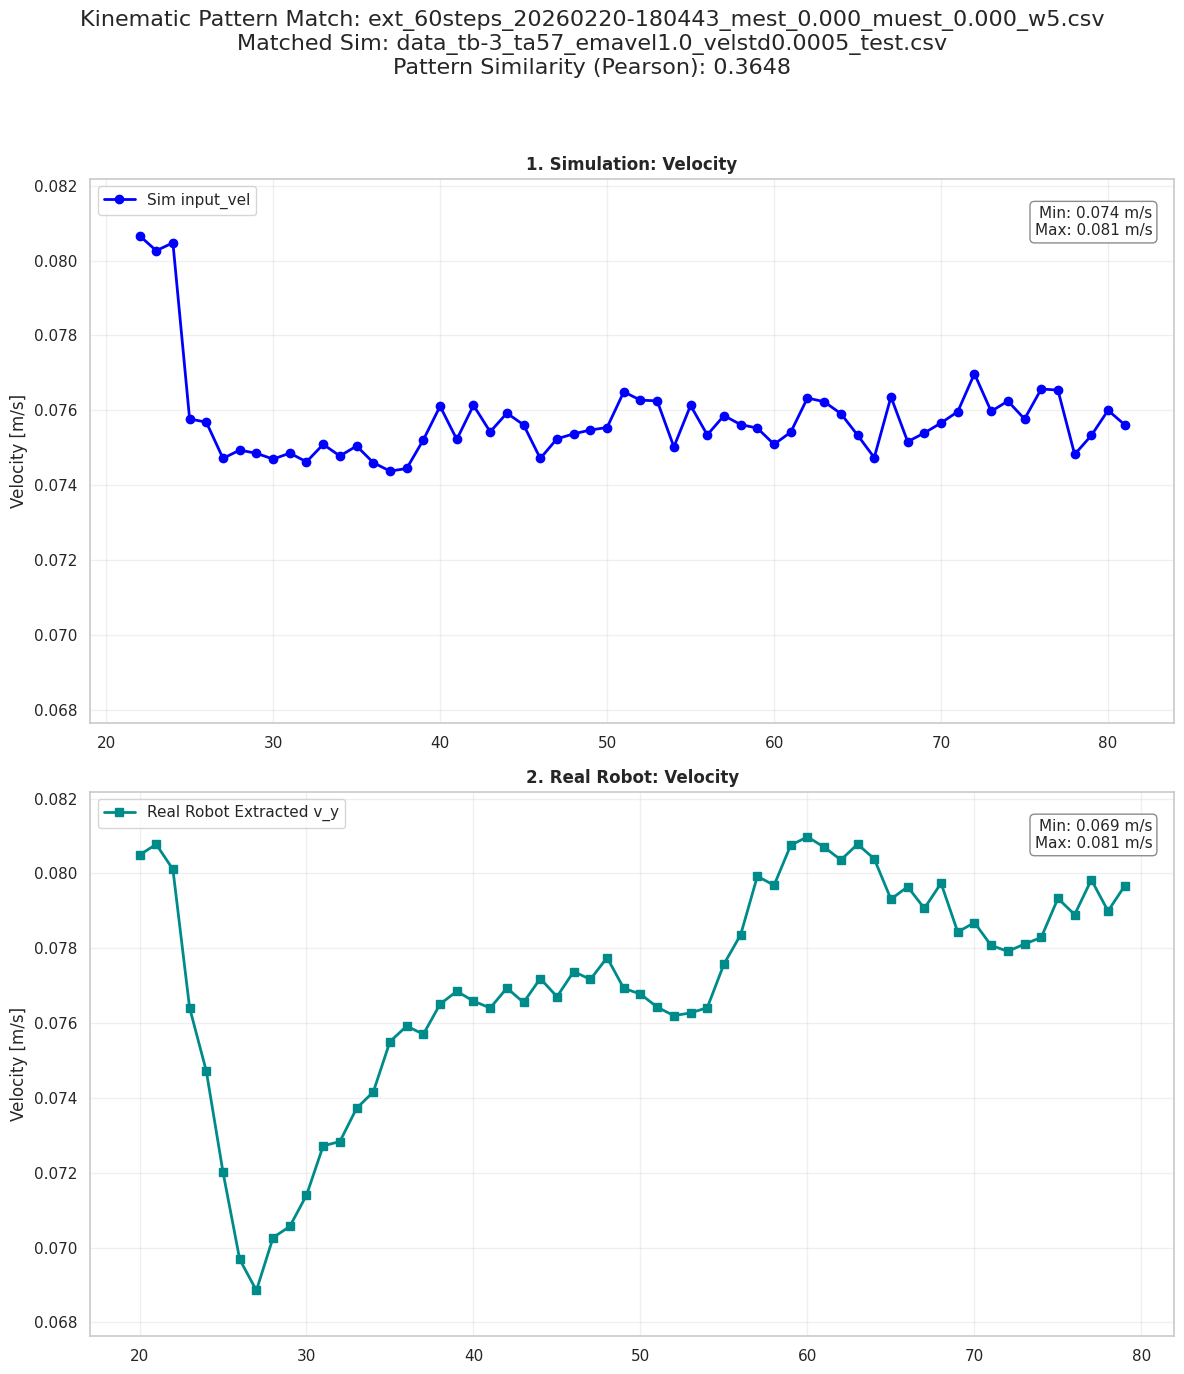


[4/10] ANALYZING REAL DATA: ext_60steps_20260220-180419_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.3261 | RMSE: 0.00482


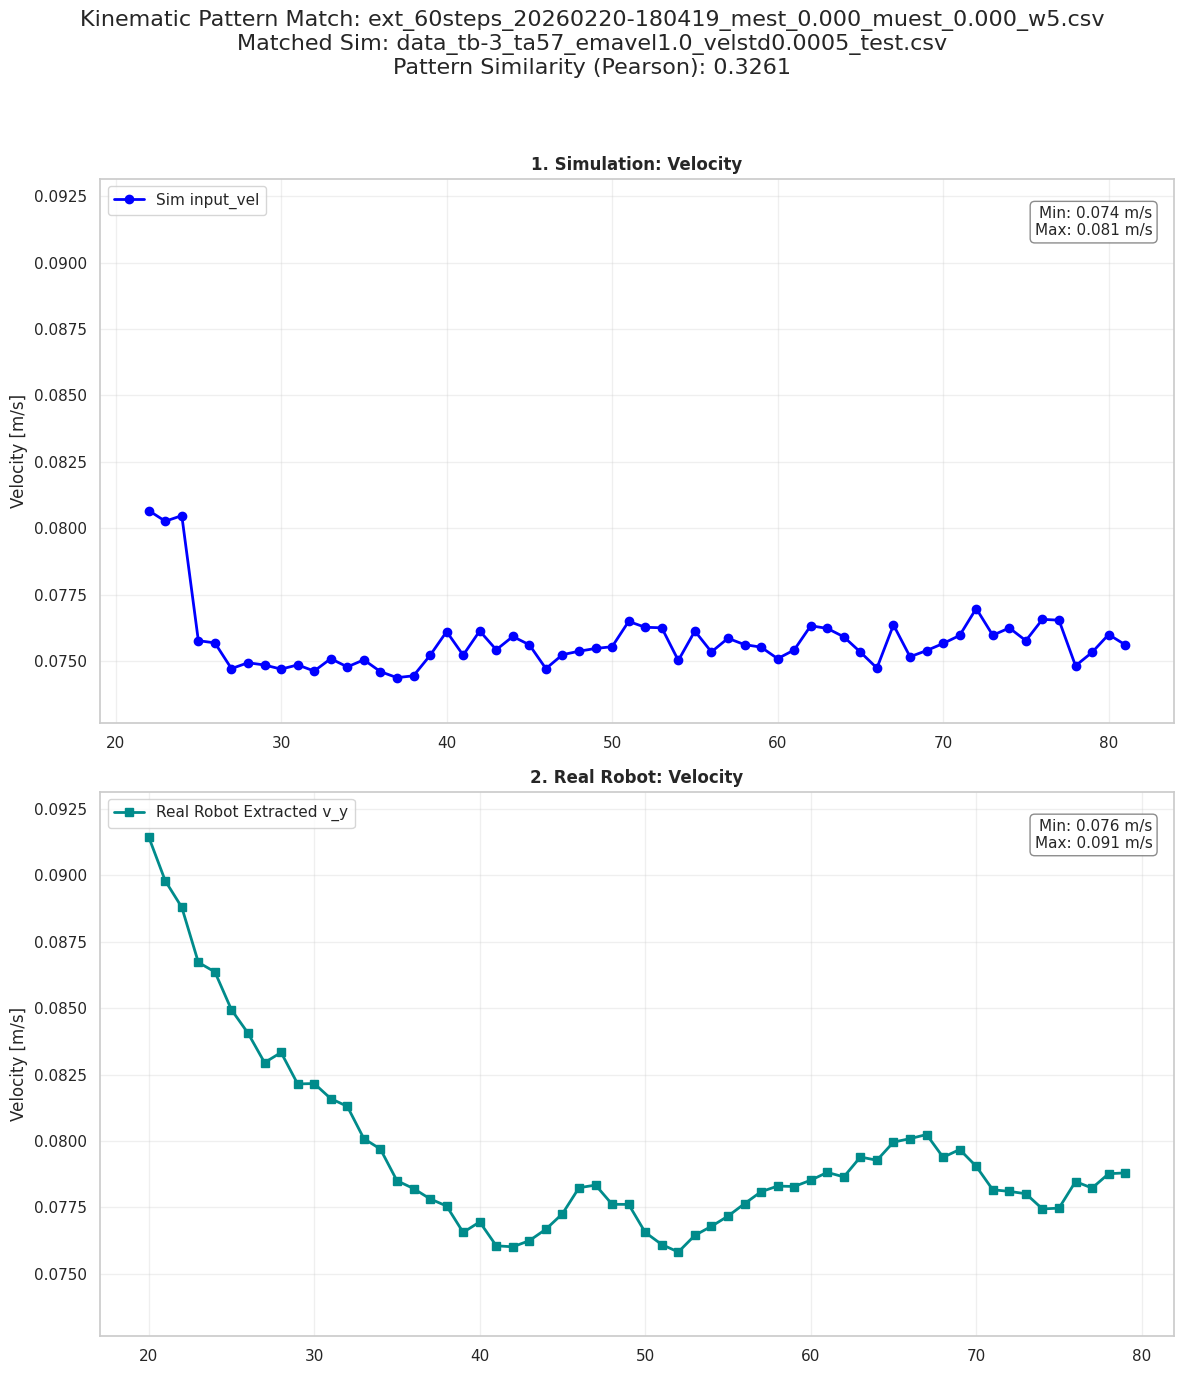


[5/10] ANALYZING REAL DATA: ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.2526 | RMSE: 0.00291


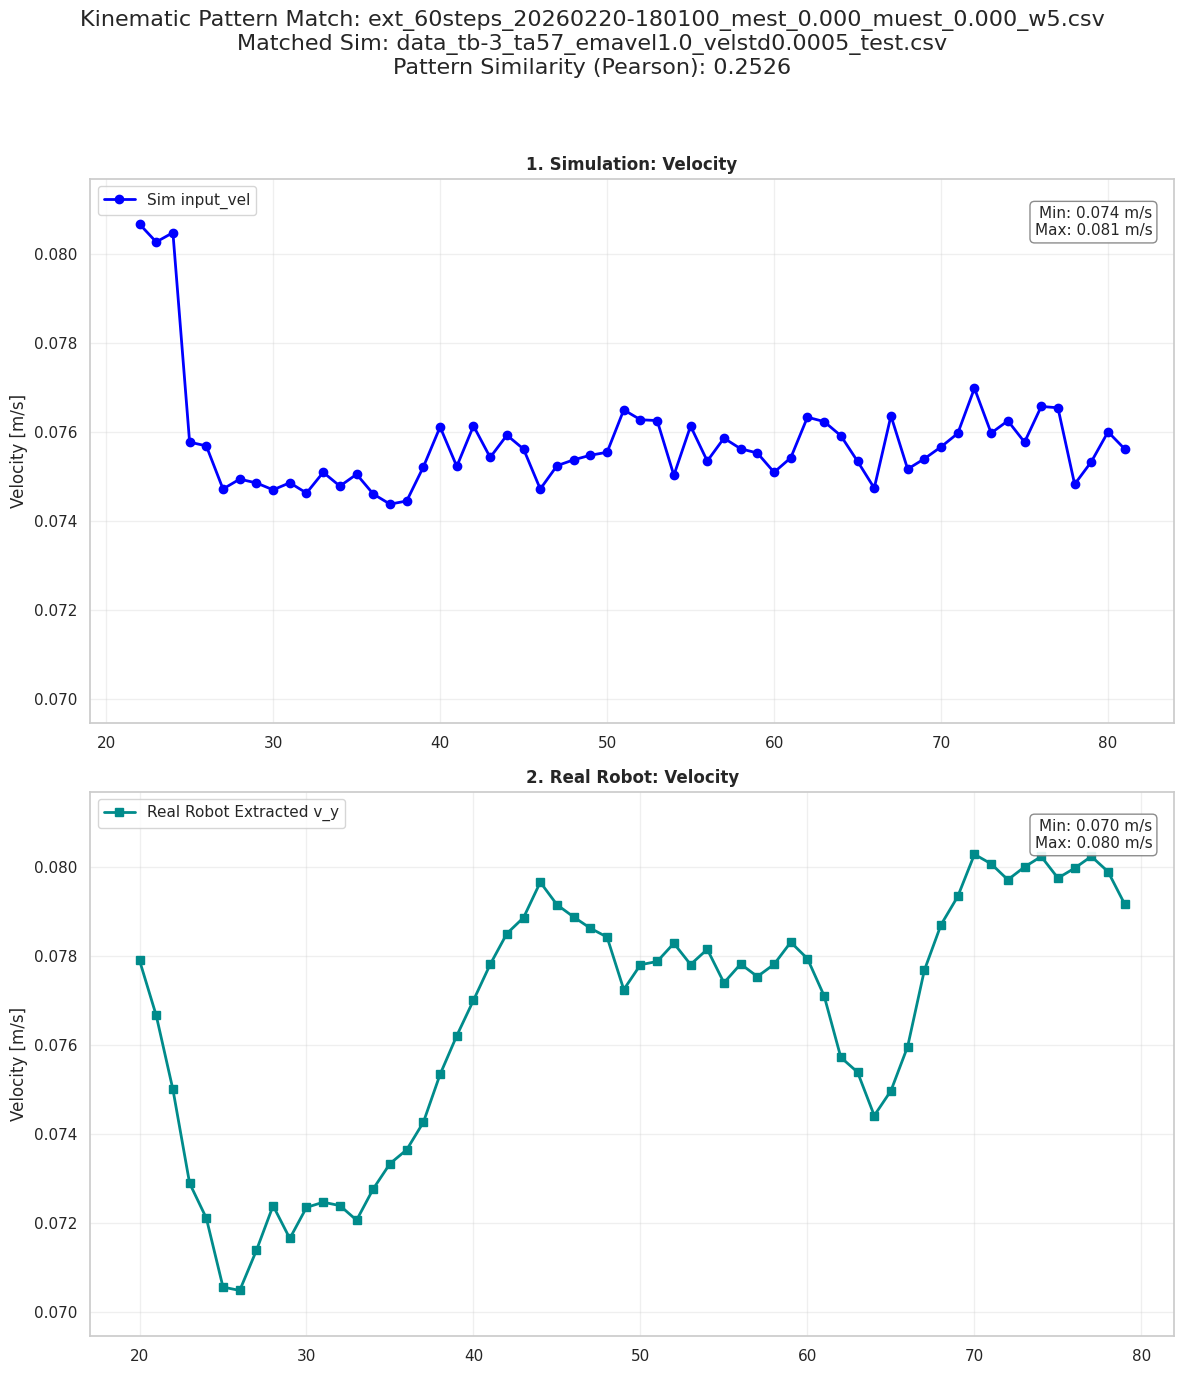


[6/10] ANALYZING REAL DATA: ext_60steps_20260220-180124_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.2378 | RMSE: 0.00285


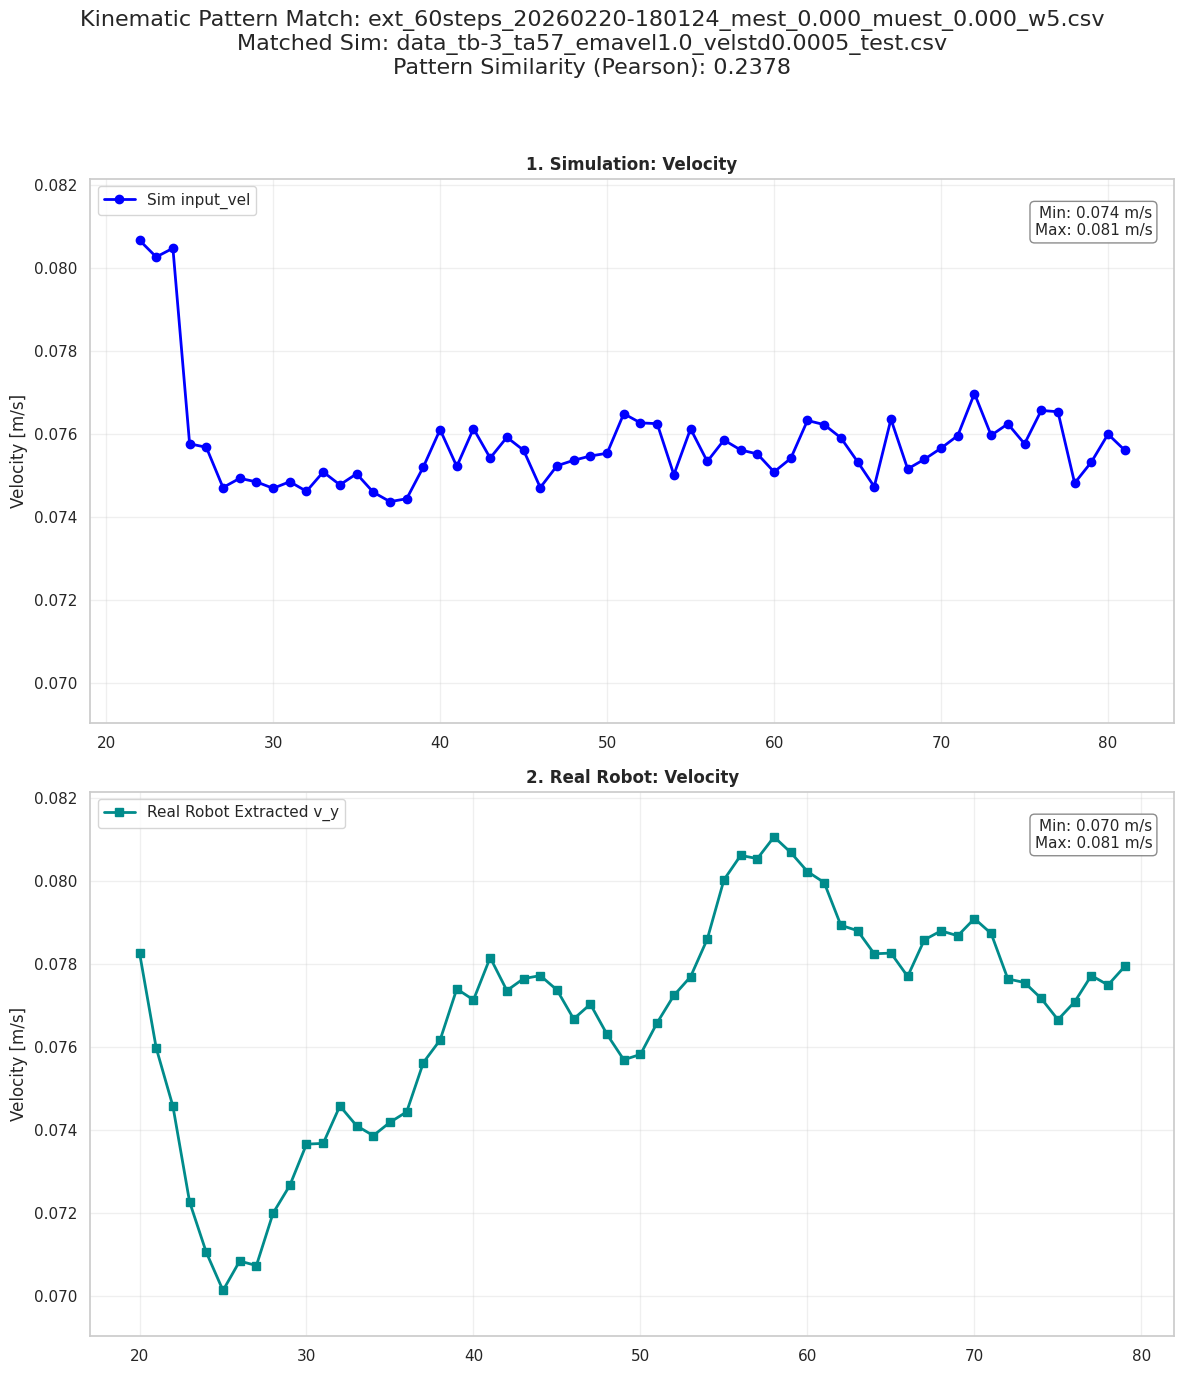


[7/10] ANALYZING REAL DATA: ext_60steps_20260220-180240_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.4793 | RMSE: 0.00270


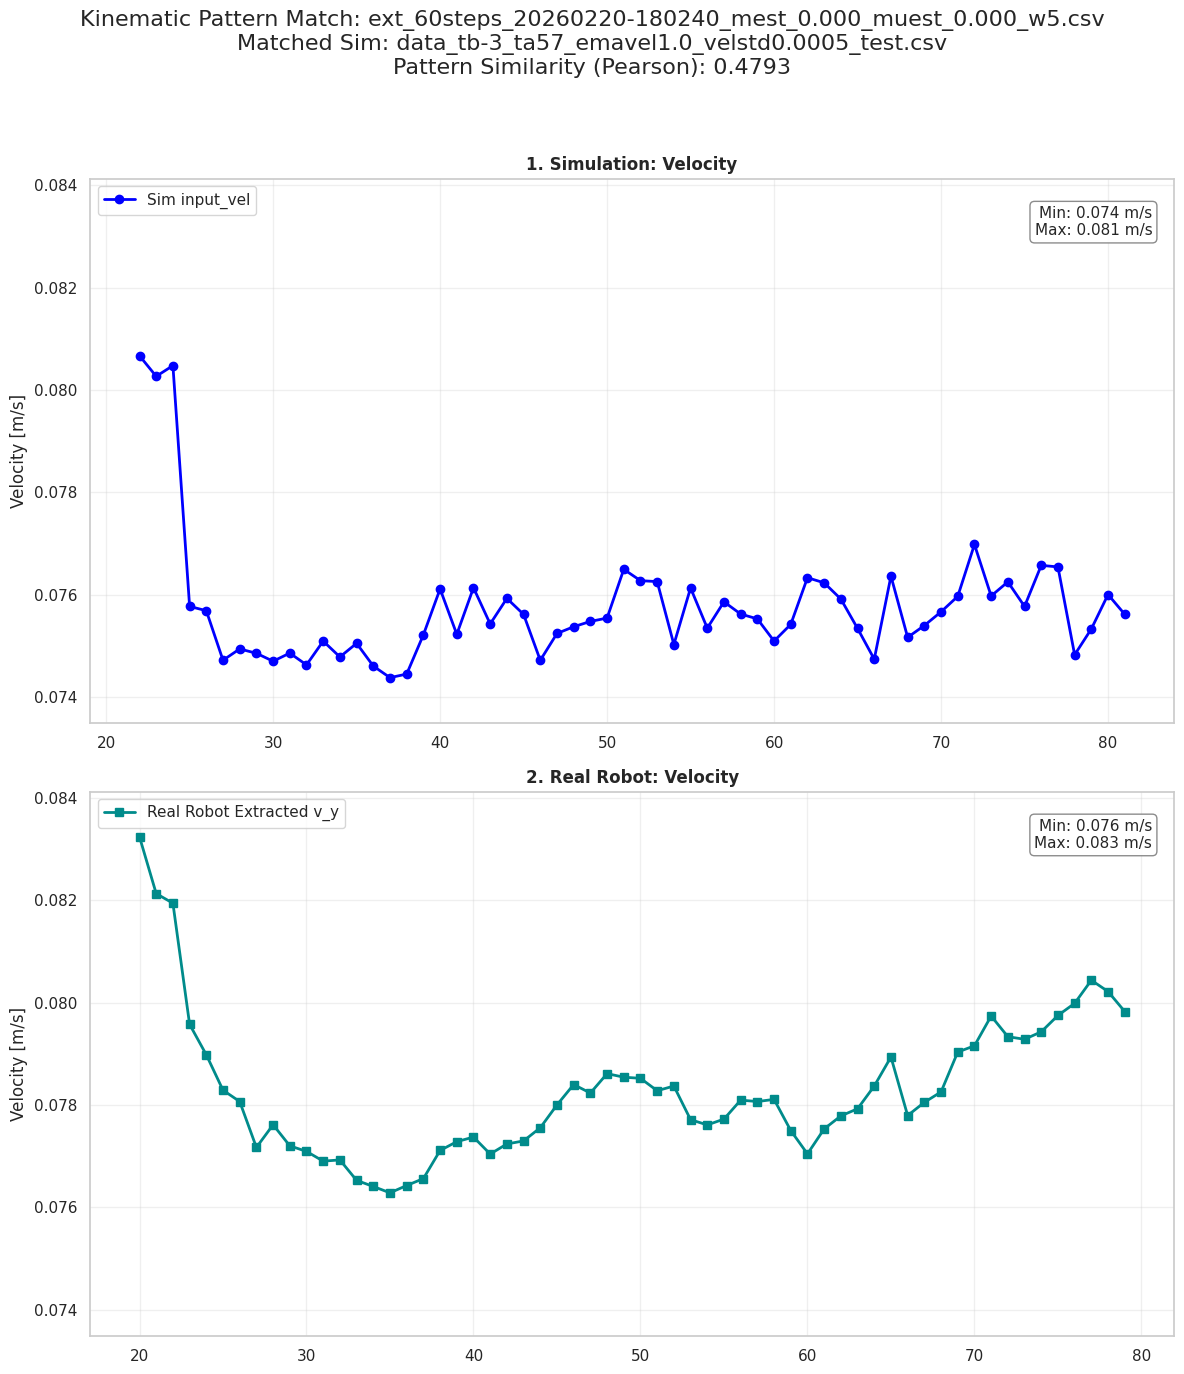


[8/10] ANALYZING REAL DATA: ext_60steps_20260220-180216_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.3345 | RMSE: 0.00366


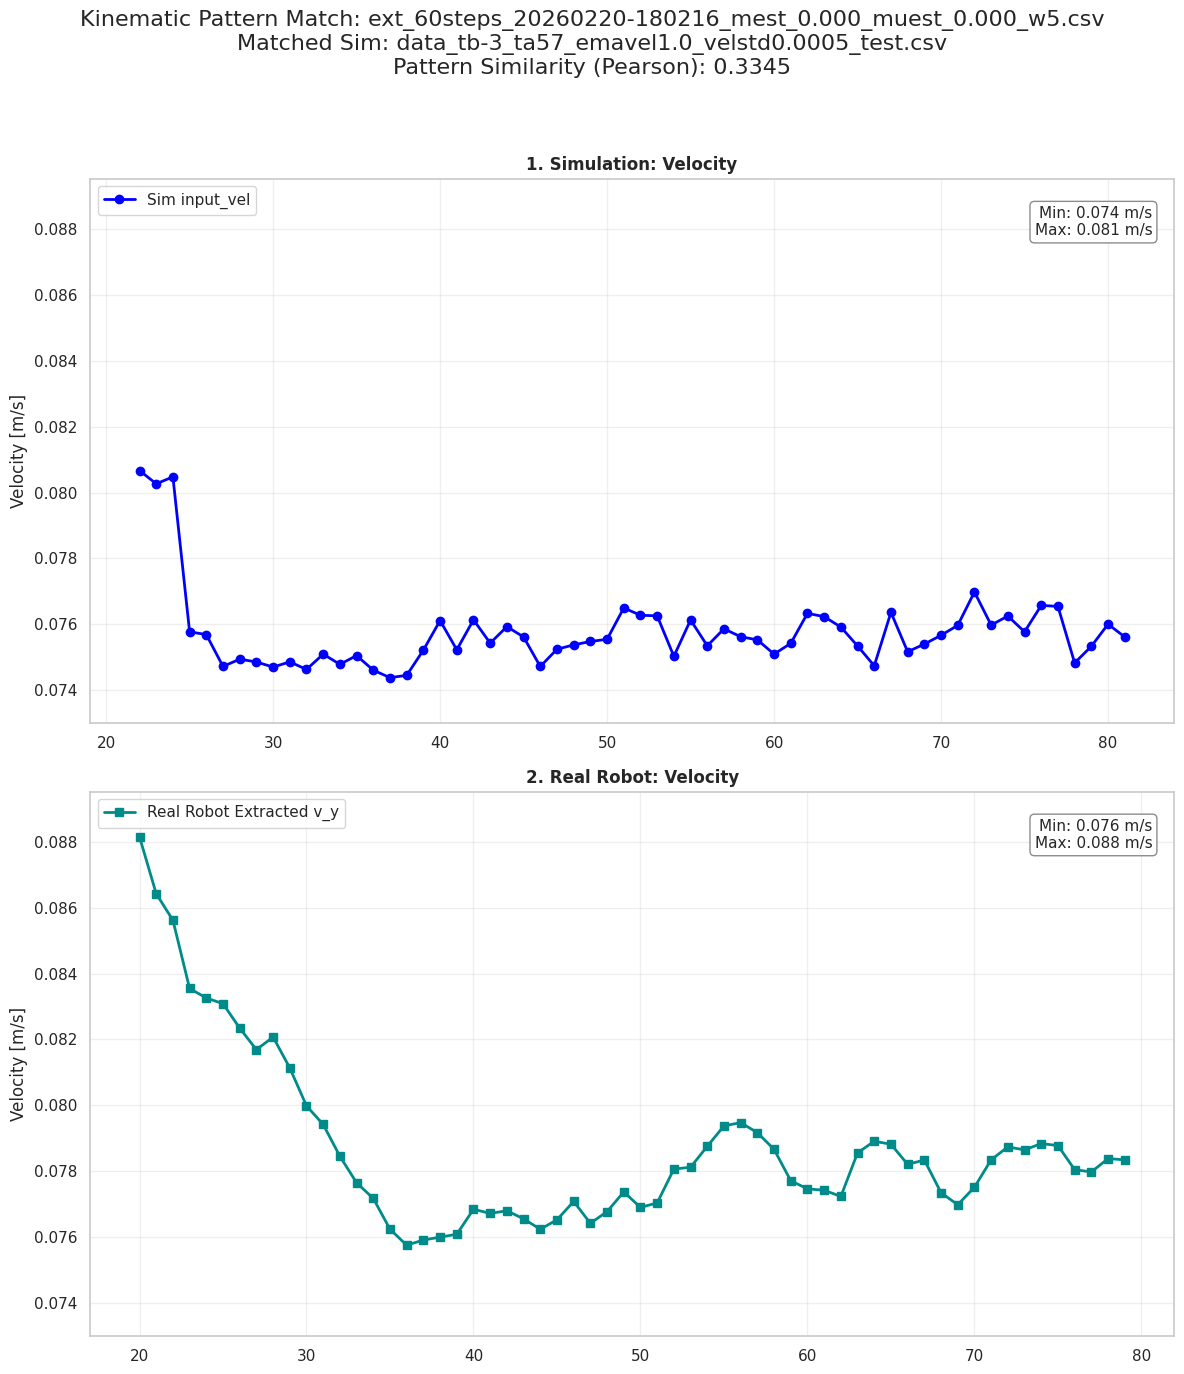


[9/10] ANALYZING REAL DATA: ext_60steps_20260220-180328_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv
   Shape Correlation: 0.3662 | RMSE: 0.00301


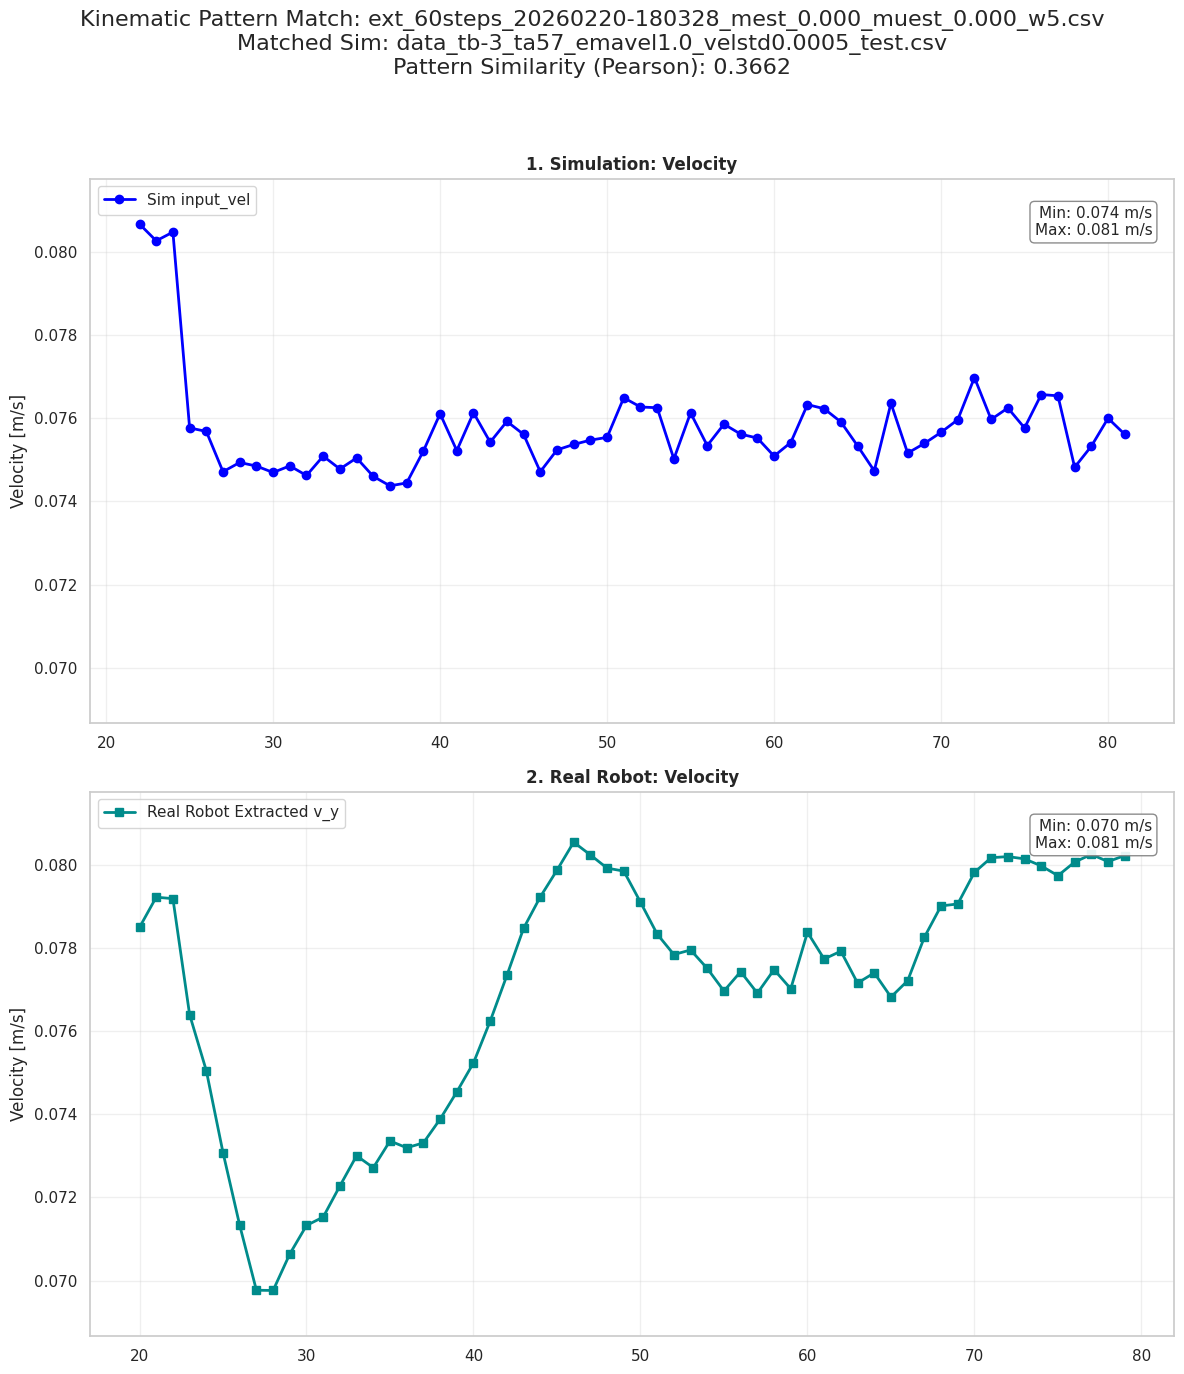


[10/10] ANALYZING REAL DATA: ext_60steps_20260220-180152_mest_0.000_muest_0.000_w5.csv
🏆 BEST PATTERN MATCH: data_tb-3_ta57_emavel0.7_velstd0.0005_test.csv
   Shape Correlation: 0.3720 | RMSE: 0.00320


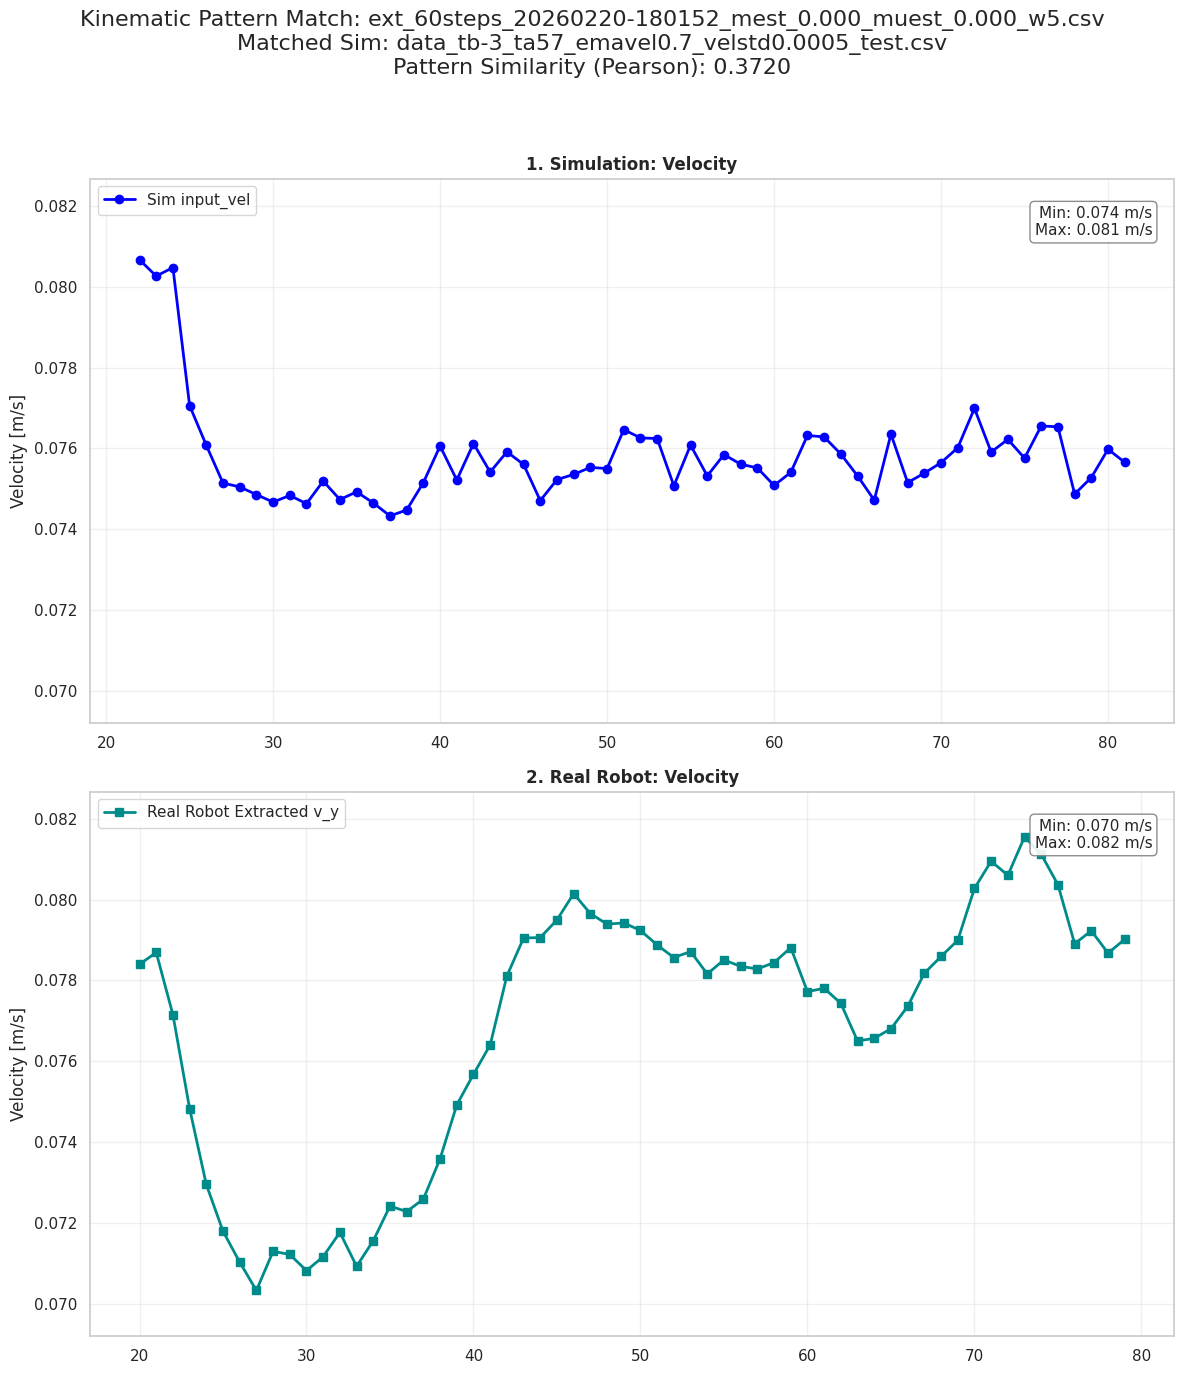

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.39      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction
AXIS_MOTION = 3         # Assuming axis 3 is your motion axis

# CHANGED: Point this to the DIRECTORY containing all your real CSVs
real_csv_dir = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/"
REAL_CSV_PATHS = glob.glob(os.path.join(real_csv_dir, "*.csv"))

# List all the simulation datasets you want to evaluate
base_dir = "/home/psxkf4/IsaacLab/source/collected_data/"


SIM_CSV_PATHS = [
    f"{base_dir}data_tb-3_ta57_emavel0.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.1_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.2_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.3_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.4_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.5_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.6_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.7_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.8_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.9_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0.csv",
]


# Helper to extract the 20-step window
def get_flat_window(row, prefix, win_len):
    return np.array([row[f"{prefix}_{i}"] for i in range(win_len)])

def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 1. PRE-LOAD SIMULATION DATA (Optimization)
# =================================================================
print("=== Pre-loading Simulation Datasets into Memory ===")
sim_cache = []

for sim_path in SIM_CSV_PATHS:
    if not os.path.exists(sim_path):
        print(f"⚠️ Warning: File not found, skipping - {os.path.basename(sim_path)}")
        continue
        
    df = pd.read_csv(sim_path)
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    
    # Store processed data so we don't have to read the CSV again
    sim_cache.append({
        'path': sim_path,
        'row': row,
        'vel': get_flat_window(row, "input_vel", win_len),
        'acc': get_flat_window(row, "input_acc", win_len),
        'win_len': win_len
    })
print(f"✅ Successfully cached {len(sim_cache)} simulation files.\n")


# =================================================================
# 2. ITERATE OVER EVERY REAL ROBOT CSV
# =================================================================
if not REAL_CSV_PATHS:
    raise FileNotFoundError(f"No real CSVs found in {real_csv_dir}")

for real_idx, real_csv_path in enumerate(REAL_CSV_PATHS):
    print(f"\n=======================================================")
    print(f"[{real_idx + 1}/{len(REAL_CSV_PATHS)}] ANALYZING REAL DATA: {os.path.basename(real_csv_path)}")
    print(f"=======================================================")
    
    # Load Real Data
    data_test = pd.read_csv(real_csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    a_csv = data_test['a_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
        a_ext = a_csv[inf_indices]
    else:
        print(f"⚠️ Skipping {os.path.basename(real_csv_path)}: No inference region found.")
        continue

    # Reset best trackers for THIS specific real file
    best_corr = -float('inf') 
    best_sim = None
    best_rmse = float('inf')

    # =================================================================
    # 3. COMPARE REAL DATA AGAINST ALL CACHED SIMULATIONS
    # =================================================================
    for sim in sim_cache:
        input_vel = sim['vel']
        
        if len(input_vel) == len(v_ext):
            # Calculate Derivatives
            sim_diff = np.diff(input_vel)
            real_diff = np.diff(v_ext)
            
            # Correlation
            corr_matrix = np.corrcoef(sim_diff + 1e-10, real_diff + 1e-10)
            shape_corr = corr_matrix[0, 1]
            if np.isnan(shape_corr): shape_corr = 0.0
            
            vel_rmse = np.sqrt(np.mean((input_vel - v_ext)**2))
            
            # Find the best match
            if shape_corr > best_corr:
                best_corr = shape_corr
                best_rmse = vel_rmse
                best_sim = sim
                
    if best_sim is None:
        print("⚠️ No matching simulation found due to length mismatch.")
        continue
        
    print(f"🏆 BEST PATTERN MATCH: {os.path.basename(best_sim['path'])}")
    print(f"   Shape Correlation: {best_corr:.4f} | RMSE: {best_rmse:.5f}")

    # =================================================================
    # 4. PREPARE BEST MATCH FOR PLOTTING
    # =================================================================
    m_val = best_sim['row']['gt_mass']
    mu_val = best_sim['row']['gt_mu']
    start_t = int(best_sim['row']['start_t'])
    
    best_input_vel = best_sim['vel']
    best_input_acc = best_sim['acc']
    time_steps = np.arange(start_t, start_t + len(best_input_vel))

    # Shared Scales
    v_min, v_max = min(np.min(best_input_vel), np.min(v_ext)), max(np.max(best_input_vel), np.max(v_ext))
    a_min, a_max = min(np.min(best_input_acc), np.min(a_ext)), max(np.max(best_input_acc), np.max(a_ext))

    v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
    shared_v_lim = (v_min - v_pad, v_max + v_pad)

    a_pad = (a_max - a_min) * 0.1 if (a_max - a_min) > 0 else 0.01
    shared_a_lim = (a_min - a_pad, a_max + a_pad)

    # =================================================================
    # 5. UNIFIED VISUALIZATION
    # =================================================================
    fig, axes = plt.subplots(2, 1, figsize=(12, 14))

    fig.suptitle(f"Kinematic Pattern Match: {os.path.basename(real_csv_path)}\nMatched Sim: {os.path.basename(best_sim['path'])}\nPattern Similarity (Pearson): {best_corr:.4f}", fontsize=16, y=0.98)

    # Velocity
    axes[0].plot(time_steps, best_input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
    axes[0].set_title("1. Simulation: Velocity", fontweight='bold')
    axes[0].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[0], best_input_vel, "m/s")
    axes[0].set_ylim(shared_v_lim)
    axes[0].legend(loc='upper left')

    axes[1].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
    axes[1].set_title(f"2. Real Robot: Velocity", fontweight='bold')
    axes[1].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[1], v_ext, "m/s")
    axes[1].set_ylim(shared_v_lim)
    axes[1].legend(loc='upper left')

    # # Acceleration
    # axes[2].plot(time_steps, best_input_acc, color='red', marker='o', linewidth=2, label='Sim input_acc')
    # axes[2].set_title("3. Simulation: Acceleration", fontweight='bold')
    # axes[2].set_ylabel("Acceleration [m/s²]")
    # add_min_max_text(axes[2], best_input_acc, "m/s²")
    # axes[2].set_ylim(shared_a_lim)
    # axes[2].legend(loc='upper left')

    # axes[3].plot(steps_ext, a_ext, color='tomato', marker='s', linewidth=2, label='Real Robot Extracted a_y')
    # axes[3].set_title("4. Real Robot: Acceleration", fontweight='bold')
    # axes[3].set_ylabel("Acceleration [m/s²]")
    # axes[3].set_xlabel("Time Step")
    # add_min_max_text(axes[3], a_ext, "m/s²")
    # axes[3].set_ylim(shared_a_lim)
    # axes[3].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    plt.close(fig) # IMPORTANT: Frees memory before looping to the next real CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =================================================================
# CONFIGURATION: Target Physics & Data Paths
# =================================================================
target_mass = 0.39      # Target GT Mass (kg)
target_mu = 0.3         # Target GT Friction

real_csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv"
base_dir = "/home/psxkf4/IsaacLab/source/collected_data/"


SIM_CSV_PATHS = [
    f"{base_dir}data_tb-3_ta57_emavel0.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.1_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.2_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.3_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.4_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.5_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.6_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.7_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.8_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel0.9_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0005_test.csv",
    f"{base_dir}data_tb-3_ta57_emavel1.0_velstd0.0.csv",
]

# Helper to extract the 20-step window
def get_flat_window(row, prefix, win_len):
    return np.array([row[f"{prefix}_{i}"] for i in range(win_len)])

# Helper for stats
def add_min_max_text(ax, data, unit=""):
    if len(data) == 0: return
    dmin, dmax = np.min(data), np.max(data)
    stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# =================================================================
# 1. LOAD REAL ROBOT DATA (Target for comparison)
# =================================================================
if os.path.exists(real_csv_path):
    data_test = pd.read_csv(real_csv_path)
    steps_csv = data_test['step_local'].values
    v_csv = data_test['v_y'].values
    is_inf = data_test['is_inference_region'].values
    
    inf_indices = np.where(is_inf == 1)[0]
    if len(inf_indices) > 0:
        steps_ext = steps_csv[inf_indices]
        v_ext = v_csv[inf_indices]
    else:
        steps_ext, v_ext = [], []
else:
    print(f"❌ Error: Real robot file not found: {real_csv_path}")
    raise FileNotFoundError("Need real robot data to compare against.")

# =================================================================
# 2. ITERATE OVER SIMULATION DATASETS AND PLOT EACH ONE
# =================================================================
print("=== Generating Velocity Plots for each Simulation Dataset ===")

for sim_path in SIM_CSV_PATHS:
    if not os.path.exists(sim_path):
        print(f"⚠️ Warning: File not found, skipping - {os.path.basename(sim_path)}")
        continue
        
    df = pd.read_csv(sim_path)
    
    # Calculate distance to target properties
    df['dist'] = np.sqrt((df['gt_mass'] - target_mass)**2 + (df['gt_mu'] - target_mu)**2)
    
    # Get the single closest sample in this specific CSV
    closest_idx = df['dist'].idxmin()
    row = df.loc[closest_idx]
    
    m_val = row['gt_mass']
    mu_val = row['gt_mu']
    
    # Extract Simulation Kinematics
    input_cols = [c for c in df.columns if "input_vel_" in c]
    win_len = len(input_cols)
    input_vel = get_flat_window(row, "input_vel", win_len)
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    
    # Calculate RMSE
    if len(input_vel) == len(v_ext):
        vel_rmse = np.sqrt(np.mean((input_vel - v_ext)**2))
    else:
        vel_rmse = float('nan')
        print(f"⚠️ Warning: Sequence length mismatch (Sim: {len(input_vel)}, Real: {len(v_ext)})")
        
    # Calculate Shared Scales for this specific pair
    if len(v_ext) > 0:
        v_min = min(np.min(input_vel), np.min(v_ext))
        v_max = max(np.max(input_vel), np.max(v_ext))
    else:
        v_min, v_max = np.min(input_vel), np.max(input_vel)

    v_pad = (v_max - v_min) * 0.1 if (v_max - v_min) > 0 else 0.01
    shared_v_lim = (v_min - v_pad, v_max + v_pad)

    # =================================================================
    # PLOT: 2 Subplots (Sim Vel vs Real Vel)
    # =================================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    filename_only = os.path.basename(sim_path)
    fig.suptitle(f"Velocity Comparison (Inference Window)\nSimulation vs Real Robot | RMSE: {vel_rmse:.5f}\nFile: {filename_only}", fontsize=14, y=0.98)
    
    # 1. SIMULATION: Velocity (20 Steps)
    axes[0].plot(time_steps, input_vel, color='blue', marker='o', linewidth=2, label='Sim input_vel')
    axes[0].set_title(f"1. Simulation (Mass: {m_val:.2f}, Mu: {mu_val:.2f})", fontweight='bold')
    axes[0].set_ylabel("Velocity [m/s]")
    add_min_max_text(axes[0], input_vel, "m/s")
    axes[0].set_ylim(shared_v_lim)
    axes[0].legend(loc='upper left')

    # 2. REAL ROBOT: Velocity (20 Steps)
    if len(v_ext) > 0:
        axes[1].plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='Real Robot Extracted v_y')
        axes[1].set_title("2. Real Robot (CSV)", fontweight='bold')
        axes[1].set_ylabel("Velocity [m/s]")
        axes[1].set_xlabel("Time Step / Step Local")
        add_min_max_text(axes[1], v_ext, "m/s")
        axes[1].set_ylim(shared_v_lim)
        axes[1].legend(loc='upper left')
    else:
        axes[1].set_title("2. Real Robot (CSV): Data Not Found", fontweight='bold')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # --- SAVING THE FIGURE IN CURRENT DIRECTORY ---
    # Construct a safe filename and save it directly in the current working directory
    safe_filename = filename_only.replace(".csv", f"_RMSE_{vel_rmse:.4f}.png")
    
    # plt.savefig(safe_filename, dpi=300, bbox_inches='tight')
    # print(f"✅ Saved plot: {safe_filename}")
    
    plt.show()
    plt.close(fig)

In [ ]:
# import os
# import glob
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # =================================================================
# # 1. CONFIGURATION
# # =================================================================
# base_dir = "/home/psxkf4/panda_phypush/csv_data"

# # Automatically find all CSV files in the base directory AND subdirectories
# csv_files = glob.glob(os.path.join(base_dir, "**", "*.csv"), recursive=True)
# csv_files.sort() # Sort alphabetically to group them logically

# # Helper to add Min/Max stats to the plots
# def add_min_max_text(ax, data, unit=""):
#     if len(data) == 0: return
#     dmin, dmax = np.min(data), np.max(data)
#     stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
#     ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
#             horizontalalignment='right', verticalalignment='top', fontsize=10,
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# # =================================================================
# # 2. CALCULATE GLOBAL SCALES
# # =================================================================
# global_v_full_min, global_v_full_max = float('inf'), float('-inf')
# global_v_ext_min, global_v_ext_max = float('inf'), float('-inf')

# print("Scanning files to calculate global y-axis limits...")
# for file_path in csv_files:
#     try:
#         df = pd.read_csv(file_path)
#         v_y = df['v_y'].values
#         is_inf = df['is_inference_region'].values
        
#         # Track 100-step bounds
#         global_v_full_min = min(global_v_full_min, np.min(v_y))
#         global_v_full_max = max(global_v_full_max, np.max(v_y))
        
#         # Track 20-step bounds
#         inf_indices = np.where(is_inf == 1)[0]
#         if len(inf_indices) > 0:
#             v_ext = v_y[inf_indices]
#             global_v_ext_min = min(global_v_ext_min, np.min(v_ext))
#             global_v_ext_max = max(global_v_ext_max, np.max(v_ext))
#     except Exception as e:
#         pass

# # Add 10% padding so lines don't touch the top/bottom borders
# def get_padded_limits(vmin, vmax):
#     pad = (vmax - vmin) * 0.1 if (vmax - vmin) > 0 else 0.01
#     return (vmin - pad, vmax + pad)

# shared_full_ylim = get_padded_limits(global_v_full_min, global_v_full_max)
# shared_ext_ylim = get_padded_limits(global_v_ext_min, global_v_ext_max)

# # =================================================================
# # 3. PLOTTING (Side-by-Side: 100 Steps vs 20 Steps)
# # =================================================================
# num_files = len(csv_files)

# if num_files == 0:
#     print(f"❌ No CSV files found in {base_dir}")
# else:
#     print(f"✅ Found {num_files} CSV files. Generating visualization...")
    
#     # Create the figure: 1 row per file, 2 columns (Full vs Extracted)
#     fig, axes = plt.subplots(num_files, 2, figsize=(16, 4 * num_files))
#     fig.suptitle("Real Robot Velocity Profiles (v_y): Full vs Inference Region", fontsize=18, fontweight='bold', y=1.01)
    
#     # Handle the case where there is only 1 file
#     if num_files == 1:
#         axes = np.expand_dims(axes, axis=0)
    
#     for i, file_path in enumerate(csv_files):
#         ax_full = axes[i, 0]
#         ax_ext = axes[i, 1]
        
#         rel_path = os.path.relpath(file_path, base_dir)
        
#         try:
#             df = pd.read_csv(file_path)
#             steps = df['step_local'].values
#             v_y = df['v_y'].values
#             is_inf = df['is_inference_region'].values
            
#             # --- LEFT PLOT: FULL SEQUENCE (100 Steps) ---
#             ax_full.plot(steps, v_y, color='teal', linewidth=2, label='v_y (Full)')
            
#             inf_indices = np.where(is_inf == 1)[0]
#             if len(inf_indices) > 0:
#                 start_inf = steps[inf_indices[0]]
#                 end_inf = steps[inf_indices[-1]]
#                 ax_full.axvspan(start_inf, end_inf, color='yellow', alpha=0.3, label='Inference Region')
            
#             ax_full.set_title(f"[{rel_path}] - Full Sequence", fontweight='bold', fontsize=11)
#             ax_full.set_xlabel("step_local")
#             ax_full.set_ylabel("Velocity [m/s]")
#             ax_full.grid(True, alpha=0.3)
#             ax_full.legend(loc='upper left')
#             add_min_max_text(ax_full, v_y, "m/s")
            
#             # APPY GLOBAL 100-STEP LIMITS
#             ax_full.set_ylim(shared_full_ylim)
            
#             # --- RIGHT PLOT: EXTRACTED INFERENCE REGION (20 Steps) ---
#             if len(inf_indices) > 0:
#                 steps_ext = steps[inf_indices]
#                 v_ext = v_y[inf_indices]
                
#                 ax_ext.plot(steps_ext, v_ext, color='darkcyan', marker='s', linewidth=2, label='v_y (Extracted)')
#                 ax_ext.set_title(f"[{rel_path}] - 20-Step Window", fontweight='bold', fontsize=11)
#                 ax_ext.set_xlabel("step_local")
#                 ax_ext.grid(True, alpha=0.3)
#                 ax_ext.legend(loc='upper left')
#                 add_min_max_text(ax_ext, v_ext, "m/s")
                
#                 # APPY GLOBAL 20-STEP LIMITS
#                 ax_ext.set_ylim(shared_ext_ylim)
#             else:
#                 ax_ext.set_title(f"[{rel_path}] - NO INFERENCE REGION FOUND", color='red', fontweight='bold')
            
#         except Exception as e:
#             ax_full.set_title(f"Error loading {rel_path}", color='red')
#             ax_full.text(0.5, 0.5, str(e), ha='center', va='center')
    
#     plt.tight_layout()
#     plt.show()

# # =================================================================
# # 4. OVERLAID COMPARISON (20-Step Only)
# # =================================================================
# plt.figure(figsize=(14, 6))
# plt.title("Overlay of All 20-Step Inference Regions (Real Robot)", fontsize=14, fontweight='bold')

# for file_path in csv_files:
#     try:
#         df = pd.read_csv(file_path)
#         is_inf = df['is_inference_region'].values
#         inf_indices = np.where(is_inf == 1)[0]
        
#         if len(inf_indices) > 0:
#             aligned_steps = np.arange(len(inf_indices)) 
#             v_ext = df['v_y'].values[inf_indices]
#             plt.plot(aligned_steps, v_ext, alpha=0.7, linewidth=1.5, marker='.', label=os.path.relpath(file_path, base_dir))
#     except:
#         pass

# plt.xlabel("Aligned Inference Step (0 to 19)")
# plt.ylabel("Velocity [m/s]")
# plt.ylim(shared_ext_ylim) # Apply the same global limits here too!
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize='small')
# plt.tight_layout()
# plt.show()

In [ ]:
# import os
# import glob
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # =================================================================
# # 1. CONFIGURATION
# # =================================================================
# base_dir = "/home/psxkf4/panda_phypush/csv_data"

# conditions = {
#     "Close0.39": os.path.join(base_dir, "mgt_0.39_close"),
#     "Open0.39": os.path.join(base_dir, "mgt_0.39_open"),
#     "Close0.76": os.path.join(base_dir, "mgt_0.76_2rs_close"),
#     "Open0.76": os.path.join(base_dir, "mgt_0.76_2rs_open"),
# }

# colors = {
#     "Close0.39": "tab:blue",
#     "Open0.39": "tab:orange",
#     "Close0.76": "tab:green",
#     "Open0.76": "tab:red",
# }

# # =================================================================
# # 2. DATA PROCESSING
# # =================================================================
# # Dictionaries to store trajectories (Dynamically initialized based on conditions)
# full_trajectories = {k: [] for k in conditions.keys()}
# inf_trajectories = {k: [] for k in conditions.keys()}

# print("=== Scanning and Loading Data ===")
# for condition_name, folder_path in conditions.items():
#     csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
#     print(f"[{condition_name}] Found {len(csv_files)} files.")
    
#     for file_path in csv_files:
#         try:
#             df = pd.read_csv(file_path)
#             v_y = df['v_y'].values
#             is_inf = df['is_inference_region'].values
            
#             # Save full 100 steps
#             full_trajectories[condition_name].append(v_y)
            
#             # Save extracted 20 steps
#             inf_indices = np.where(is_inf == 1)[0]
#             if len(inf_indices) > 0:
#                 inf_trajectories[condition_name].append(v_y[inf_indices])
                
#         except Exception as e:
#             print(f"Error loading {file_path}: {e}")

# # Convert to numpy arrays for easy math (Shape: [Num_Trials, Time_Steps])
# for condition_name in conditions.keys():
#     if len(full_trajectories[condition_name]) > 0:
#         full_trajectories[condition_name] = np.array(full_trajectories[condition_name])
#     if len(inf_trajectories[condition_name]) > 0:
#         inf_trajectories[condition_name] = np.array(inf_trajectories[condition_name])

# # =================================================================
# # 3. CALCULATE CONSISTENCY METRICS (Standard Deviation)
# # =================================================================
# print("\n=== CONSISTENCY REPORT (Lower Std Dev = More Similar Data) ===")
# stats = {}

# for condition_name in conditions.keys():
#     if len(full_trajectories[condition_name]) == 0:
#         print(f"[{condition_name} Condition] -> No data found. Skipping.")
#         continue

#     # Calculate point-wise standard deviation, then take the mean across all time steps
#     full_std = np.std(full_trajectories[condition_name], axis=0).mean()
#     inf_std = np.std(inf_trajectories[condition_name], axis=0).mean()
    
#     stats[condition_name] = {"full_std": full_std, "inf_std": inf_std}
    
#     print(f"[{condition_name} Condition]")
#     print(f"  -> Full Sequence Avg Std Dev: {full_std:.5f} m/s")
#     print(f"  -> Inference Reg Avg Std Dev: {inf_std:.5f} m/s")

# # Identify the winner
# if stats:
#     best_full = min(stats, key=lambda k: stats[k]['full_std'])
#     best_inf = min(stats, key=lambda k: stats[k]['inf_std'])
#     print(f"\n🏆 Most Consistent Overall (Full): {best_full}")
#     print(f"🏆 Most Consistent in Inference Region: {best_inf}")

# # =================================================================
# # 4. VISUALIZATION
# # =================================================================
# num_conditions = len(conditions)
# fig, axes = plt.subplots(2, num_conditions, figsize=(6 * num_conditions, 10))
# fig.suptitle("Velocity (v_y) Consistency Comparison Across All Conditions", fontsize=18, fontweight='bold')

# for col, condition_name in enumerate(conditions.keys()):
#     if len(full_trajectories[condition_name]) == 0:
#         continue

#     color = colors[condition_name]
#     full_data = full_trajectories[condition_name]
#     inf_data = inf_trajectories[condition_name]
    
#     # ---------------------------------------------------
#     # ROW 1: FULL SEQUENCE OVERLAYS + MEAN/STD
#     # ---------------------------------------------------
#     ax_full = axes[0, col]
#     # Plot all individual lines faintly
#     for traj in full_data:
#         ax_full.plot(traj, color=color, alpha=0.2, linewidth=1)
        
#     # Plot Mean and Std Dev Band
#     mean_full = np.mean(full_data, axis=0)
#     std_full = np.std(full_data, axis=0)
#     steps_full = np.arange(len(mean_full))
    
#     ax_full.plot(steps_full, mean_full, color=color, linewidth=3, label=f'{condition_name} Mean')
#     ax_full.fill_between(steps_full, mean_full - std_full, mean_full + std_full, color=color, alpha=0.3, label='±1 Std Dev')
    
#     ax_full.set_title(f"{condition_name}\nFull Sequence (Std: {stats[condition_name]['full_std']:.5f})", fontweight='bold')
#     ax_full.set_xlabel("Time Step")
#     if col == 0: ax_full.set_ylabel("Velocity [m/s]")
#     ax_full.grid(True, alpha=0.3)
#     ax_full.legend(loc='upper left')

#     # ---------------------------------------------------
#     # ROW 2: INFERENCE REGION (20 STEPS)
#     # ---------------------------------------------------
#     ax_inf = axes[1, col]
#     # Plot all individual lines faintly
#     if len(inf_data) > 0:
#         for traj in inf_data:
#             ax_inf.plot(traj, color=color, alpha=0.3, linewidth=1.5, marker='.')
            
#         # Plot Mean and Std Dev Band
#         mean_inf = np.mean(inf_data, axis=0)
#         std_inf = np.std(inf_data, axis=0)
#         steps_inf = np.arange(len(mean_inf))
        
#         ax_inf.plot(steps_inf, mean_inf, color=color, linewidth=3, label=f'{condition_name} Mean')
#         ax_inf.fill_between(steps_inf, mean_inf - std_inf, mean_inf + std_inf, color=color, alpha=0.3)
        
#         ax_inf.set_title(f"{condition_name}\n20-Step Window (Std: {stats[condition_name]['inf_std']:.5f})", fontweight='bold')
#         ax_inf.set_xlabel("Aligned Inference Step (0 to 19)")
#         if col == 0: ax_inf.set_ylabel("Velocity [m/s]")
#         ax_inf.grid(True, alpha=0.3)
#         ax_inf.legend(loc='upper left')

# # Align Y-axes dynamically for all columns
# # 1. Full plots scale
# valid_full_data = [full_trajectories[c] for c in conditions.keys() if len(full_trajectories[c]) > 0]
# if valid_full_data:
#     global_full_min = min([np.min(data) for data in valid_full_data])
#     global_full_max = max([np.max(data) for data in valid_full_data])
#     pad_full = (global_full_max - global_full_min) * 0.1
#     for col in range(num_conditions):
#         axes[0, col].set_ylim(global_full_min - pad_full, global_full_max + pad_full)

# # 2. Inf plots scale
# valid_inf_data = [inf_trajectories[c] for c in conditions.keys() if len(inf_trajectories[c]) > 0]
# if valid_inf_data:
#     global_inf_min = min([np.min(data) for data in valid_inf_data])
#     global_inf_max = max([np.max(data) for data in valid_inf_data])
#     pad_inf = (global_inf_max - global_inf_min) * 0.1
#     for col in range(num_conditions):
#         axes[1, col].set_ylim(global_inf_min - pad_inf, global_inf_max + pad_inf)

# plt.tight_layout()
# plt.show()

=== Analyzing Real Hardware Noise Frequency ===
✅ Extracted Hardware Noise Std Dev (σ_t): 0.001510


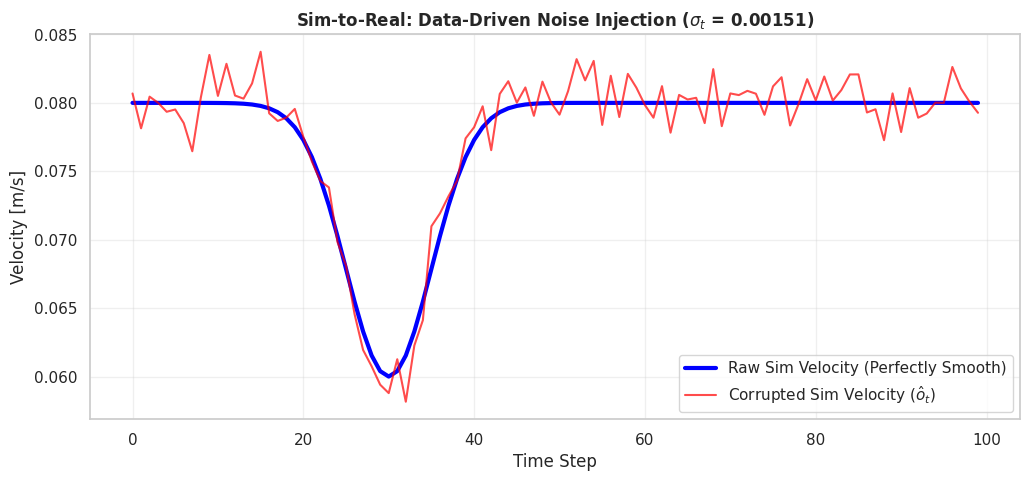

In [12]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# CONFIGURATION
# =================================================================
real_csv_dir = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/"
REAL_CSV_PATHS = glob.glob(os.path.join(real_csv_dir, "*.csv"))

# Set your robot's control/logging frequency here (e.g., 50 Hz, 100 Hz, 1000 Hz)
FS = 100.0  

# =================================================================
# STEP 1-4: EXTRACT DATA-DRIVEN NOISE SIGMA FROM REAL ROBOT
# =================================================================
def extract_noise_profile(csv_paths, fs):
    extracted_sigmas = []
    
    for file_path in csv_paths:
        df = pd.read_csv(file_path)
        # Use the FULL sequence (100 steps) for better frequency resolution
        v_y = df['v_y'].values 
        N = len(v_y)
        
        # Step 2: Frequency Domain Transformation (FFT)
        # Use rfft since our velocity data is strictly real numbers
        fft_values = np.fft.rfft(v_y)
        # Normalize by N to get actual physical amplitudes
        fft_amps = np.abs(fft_values) / N 
        freqs = np.fft.rfftfreq(N, d=1.0/fs)
        
        # Step 3: Normalization (Multiply by frequency f)
        norm_amps = fft_amps * freqs
        
        # Step 4: Estimating the Noise Variance
        # Isolate the right half of the frequency domain: [fs/4, fs/2]
        nyquist = fs / 2.0
        lower_bound = fs / 4.0
        
        # Create a boolean mask for the target frequency range
        band_mask = (freqs >= lower_bound) & (freqs <= nyquist)
        
        # Compute average signal power in this band
        if np.any(band_mask):
            band_power = np.mean(norm_amps[band_mask]**2)
            sigma_t = np.sqrt(band_power)
            extracted_sigmas.append(sigma_t)
            
    # Return the average standard deviation across all real trials
    global_sigma = np.mean(extracted_sigmas)
    return global_sigma

print("=== Analyzing Real Hardware Noise Frequency ===")
data_driven_sigma = extract_noise_profile(REAL_CSV_PATHS, fs=FS)
print(f"✅ Extracted Hardware Noise Std Dev (\u03c3_t): {data_driven_sigma:.6f}")

# =================================================================
# STEP 5: NOISE INJECTION FUNCTION (For Simulator / Dataloader)
# =================================================================
def inject_data_driven_noise(sim_velocity, sigma_t):
    """
    Applies the physically extracted white noise to the simulated velocity.
    sim_velocity: numpy array or torch tensor
    sigma_t: The data-driven standard deviation calculated above
    """
    # Sample noise n_t ~ N(0, sigma_t)
    if isinstance(sim_velocity, np.ndarray):
        noise = np.random.normal(loc=0.0, scale=sigma_t, size=sim_velocity.shape)
    else: # PyTorch tensor handling
        import torch
        noise = torch.normal(mean=0.0, std=sigma_t, size=sim_velocity.shape, device=sim_velocity.device)
        
    # Corrupted observation: o^_t = o_t + n_t
    corrupted_velocity = sim_velocity + noise
    return corrupted_velocity

# =================================================================
# VISUALIZATION: Seeing the effect on a dummy signal
# =================================================================
# Let's visualize what this noise looks like when added to a smooth simulation curve
dummy_sim_steps = np.arange(100)
# A perfectly smooth, fake simulated velocity dip
dummy_sim_vel = 0.08 - 0.02 * np.exp(-0.5 * ((dummy_sim_steps - 30) / 5)**2) 

corrupted_sim_vel = inject_data_driven_noise(dummy_sim_vel, data_driven_sigma)

plt.figure(figsize=(12, 5))
plt.title(f"Sim-to-Real: Data-Driven Noise Injection ($\sigma_t$ = {data_driven_sigma:.5f})", fontweight='bold')
plt.plot(dummy_sim_steps, dummy_sim_vel, label='Raw Sim Velocity (Perfectly Smooth)', color='blue', linewidth=3)
plt.plot(dummy_sim_steps, corrupted_sim_vel, label='Corrupted Sim Velocity ($\hat{o}_t$)', color='red', alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

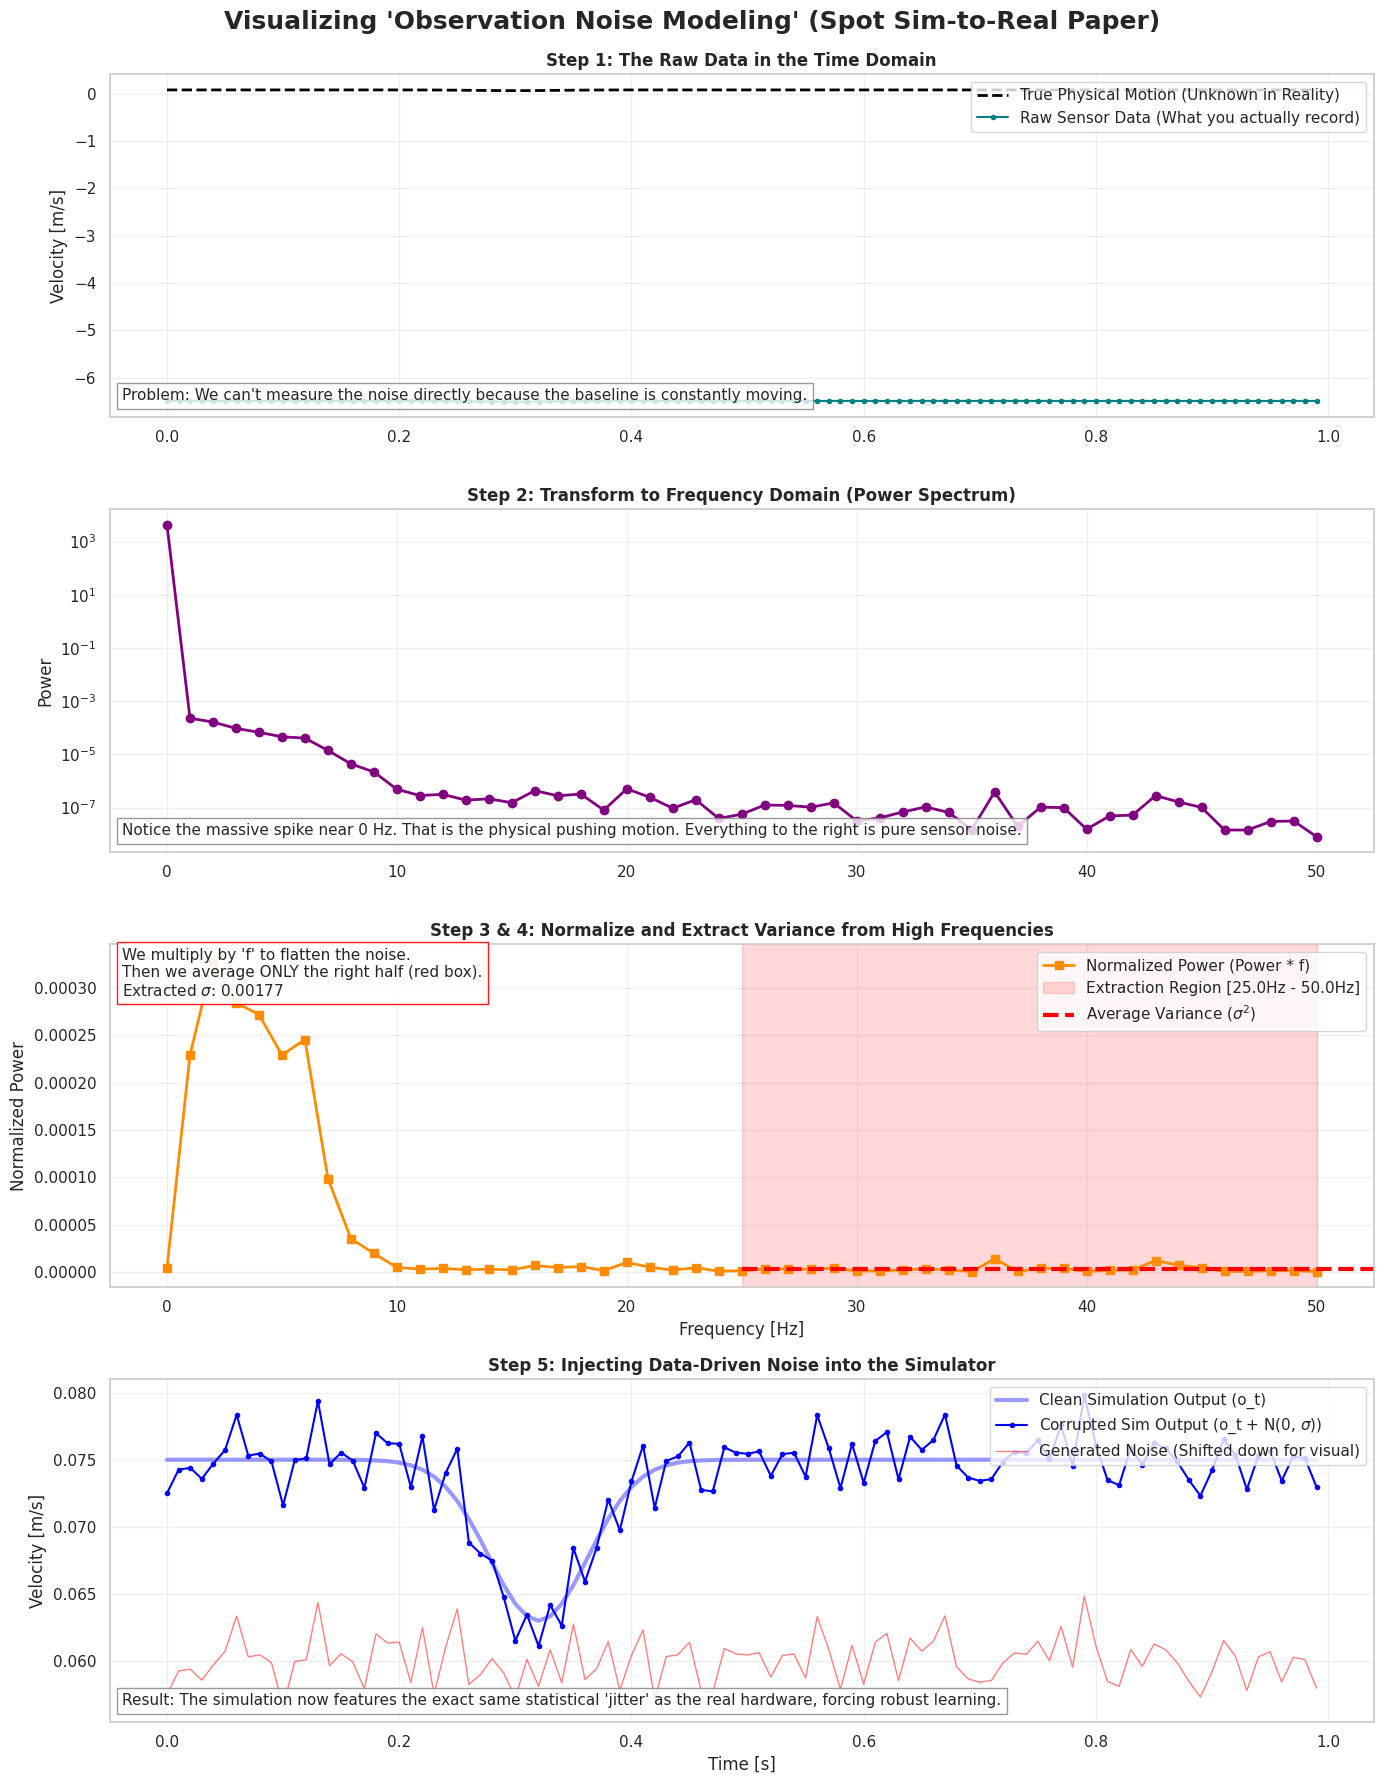

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 0. SETUP & SYNTHETIC DATA GENERATION
# =================================================================
fs = 100.0          # Control frequency (100 Hz)
N = 100             # 100 steps (1 second of data)
t = np.arange(N) / fs

# 1. Simulate the "True" Physical Motion (Low Frequency)
# This is a smooth velocity drop, mimicking your physical impact
true_motion = 0.08 - 0.015 * np.exp(-((t - 0.3) / 0.05)**2)

# 2. Simulate Sensor Noise (Pink/Red Noise is common in hardware)
# We generate white noise, then artificially boost the low frequencies
np.random.seed(42)
white_noise = np.random.normal(0, 0.002, N)
noise_fft = np.fft.rfft(white_noise)
freqs_for_gen = np.fft.rfftfreq(N, d=1.0/fs)
# Dampen high frequencies to simulate realistic hardware 1/f noise
noise_fft_pink = noise_fft / np.sqrt(freqs_for_gen + 1e-9) 
real_hardware_noise = np.fft.irfft(noise_fft_pink, n=N)

# The data you would get from your CSV:
real_robot_data = true_motion + real_hardware_noise

# =================================================================
# 1. FFT AND NORMALIZATION (The Paper's Algorithm)
# =================================================================
# Step A: Fast Fourier Transform
fft_vals = np.fft.rfft(real_robot_data)
freqs = np.fft.rfftfreq(N, d=1.0/fs)

# Step B: Power Spectral Density (PSD)
power = (np.abs(fft_vals) ** 2) / N

# Step C: Normalize by multiplying by frequency f
norm_power = power * (freqs + 1e-9)

# Step D: Extract Sigma from the right half [fs/4, fs/2]
nyquist = fs / 2.0
lower_bound = fs / 4.0
high_freq_mask = (freqs >= lower_bound) & (freqs <= nyquist)

# Average normalized power in the target region
noise_variance = np.mean(norm_power[high_freq_mask])
extracted_sigma = np.sqrt(noise_variance)

# =================================================================
# 2. VISUALIZATION DASHBOARD
# =================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 18))
fig.suptitle("Visualizing 'Observation Noise Modeling' (Spot Sim-to-Real Paper)", fontsize=18, fontweight='bold', y=0.99)

# ---------------------------------------------------------
# PLOT 1: Time Domain (The Raw Data)
# ---------------------------------------------------------
ax = axes[0]
ax.plot(t, true_motion, color='black', linestyle='--', linewidth=2, label='True Physical Motion (Unknown in Reality)')
ax.plot(t, real_robot_data, color='teal', linewidth=1.5, marker='.', label='Raw Sensor Data (What you actually record)')
ax.set_title("Step 1: The Raw Data in the Time Domain", fontweight='bold')
ax.set_ylabel("Velocity [m/s]")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.text(0.01, 0.05, "Problem: We can't measure the noise directly because the baseline is constantly moving.", 
        transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# ---------------------------------------------------------
# PLOT 2: Frequency Domain (FFT)
# ---------------------------------------------------------
ax = axes[1]
ax.plot(freqs, power, color='purple', marker='o', linewidth=2)
ax.set_title("Step 2: Transform to Frequency Domain (Power Spectrum)", fontweight='bold')
ax.set_ylabel("Power")
ax.set_yscale('log') # Log scale is necessary to see the tiny noise next to the massive movement
ax.grid(True, alpha=0.3)
ax.text(0.01, 0.05, "Notice the massive spike near 0 Hz. That is the physical pushing motion. Everything to the right is pure sensor noise.", 
        transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# ---------------------------------------------------------
# PLOT 3: Normalization & Extraction
# ---------------------------------------------------------
ax = axes[2]
ax.plot(freqs, norm_power, color='darkorange', marker='s', linewidth=2, label='Normalized Power (Power * f)')
ax.axvspan(lower_bound, nyquist, color='red', alpha=0.15, label=f'Extraction Region [{lower_bound}Hz - {nyquist}Hz]')
ax.axhline(noise_variance, xmin=0.5, xmax=1.0, color='red', linestyle='--', linewidth=3, label=f'Average Variance ($\sigma^2$)')

ax.set_title("Step 3 & 4: Normalize and Extract Variance from High Frequencies", fontweight='bold')
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Frequency [Hz]")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.text(0.01, 0.85, f"We multiply by 'f' to flatten the noise.\nThen we average ONLY the right half (red box).\nExtracted $\sigma$: {extracted_sigma:.5f}", 
        transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='red'))

# ---------------------------------------------------------
# PLOT 4: Injecting back into Simulation
# ---------------------------------------------------------
ax = axes[3]
# Imagine this is your perfectly smooth IsaacLab simulation output
clean_sim_motion = 0.075 - 0.012 * np.exp(-((t - 0.32) / 0.06)**2)

# Generate White Noise using the extracted sigma!
synthetic_noise = np.random.normal(0, extracted_sigma, N)
corrupted_sim = clean_sim_motion + synthetic_noise

ax.plot(t, clean_sim_motion, color='blue', linewidth=3, alpha=0.4, label='Clean Simulation Output (o_t)')
ax.plot(t, corrupted_sim, color='blue', linewidth=1.5, marker='.', label=f'Corrupted Sim Output (o_t + N(0, $\sigma$))')
ax.plot(t, synthetic_noise + 0.06, color='red', alpha=0.5, linewidth=1, label="Generated Noise (Shifted down for visual)")

ax.set_title("Step 5: Injecting Data-Driven Noise into the Simulator", fontweight='bold')
ax.set_ylabel("Velocity [m/s]")
ax.set_xlabel("Time [s]")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.text(0.01, 0.05, "Result: The simulation now features the exact same statistical 'jitter' as the real hardware, forcing robust learning.", 
        transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

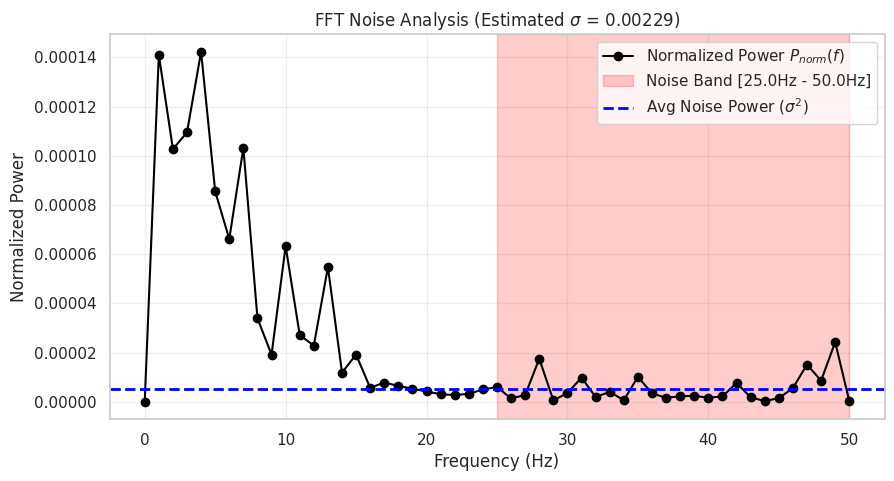

Data-driven standard deviation for Gaussian Noise: 0.002292


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extract_noise_std_from_real_data(real_velocity_sequence, fs=100.0, show_plot=False):
    """
    Implements the Observation Noise Modeling from the Spot sim-to-real paper.
    
    Args:
        real_velocity_sequence: numpy array of real robot velocity (e.g., 100 steps)
        fs: Control frequency of your robot in Hz (Assumed 100 Hz for Panda)
        show_plot: Boolean to display the FFT analysis
        
    Returns:
        sigma: The extracted standard deviation of the high-frequency noise
    """
    N = len(real_velocity_sequence)
    
    # 1. Frequency Domain Transformation (FFT)
    # rfft returns only the positive frequencies (which is all we need)
    fft_vals = np.fft.rfft(real_velocity_sequence)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    
    # 2. Calculate Power Spectrum
    power = (np.abs(fft_vals) ** 2) / N
    
    # 3. Normalization (Multiply by frequency f)
    # We add a tiny epsilon to freqs to avoid multiplying the 0Hz (DC offset) by 0
    norm_power = power * (freqs + 1e-9)
    
    # 4. Estimate Noise Variance (Average over right half of frequency domain)
    # The domain is [0, fs/2]. The right half is [fs/4, fs/2].
    nyquist = fs / 2.0
    lower_bound = fs / 4.0
    
    # Create a boolean mask for the high-frequency band
    high_freq_mask = (freqs >= lower_bound) & (freqs <= nyquist)
    
    # Calculate the average power in this high-frequency band
    # This represents our noise variance (sigma^2)
    noise_variance = np.mean(norm_power[high_freq_mask])
    
    # The standard deviation is the square root of the variance
    sigma = np.sqrt(noise_variance)
    
    # --- Optional Visualization to help you understand it ---
    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.plot(freqs, norm_power, marker='o', linestyle='-', color='black', label='Normalized Power $P_{norm}(f)$')
        plt.axvspan(lower_bound, nyquist, color='red', alpha=0.2, label=f'Noise Band [{lower_bound}Hz - {nyquist}Hz]')
        plt.axhline(noise_variance, color='blue', linestyle='--', linewidth=2, label=f'Avg Noise Power ($\sigma^2$)')
        plt.title(f"FFT Noise Analysis (Estimated $\sigma$ = {sigma:.5f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Normalized Power")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
    return sigma

# =========================================================
# EXAMPLE OF HOW TO USE THIS IN YOUR PIPELINE
# =========================================================

# 1. Load one of your real CSVs
real_csv_path = "/home/psxkf4/panda_phypush/csv_data/mgt_0.39_60_rub_w5/ext_60steps_20260220-180100_mest_0.000_muest_0.000_w5.csv"
real_df = pd.read_csv(real_csv_path)

# Use the FULL sequence (100 steps) to get a good frequency resolution
real_full_vy = real_df['v_y'].values

# 2. Extract the mathematically accurate noise profile
# Assuming your robot control loop runs at 100 Hz
estimated_sigma = extract_noise_std_from_real_data(real_full_vy, fs=100.0, show_plot=True)

print(f"Data-driven standard deviation for Gaussian Noise: {estimated_sigma:.6f}")

# 3. Apply it to your Simulation Data (During your training loop)
# Suppose you have your 20-step simulated velocity sequence:
# sim_v_ext = np.array([...20 steps...])

# Create the noise based on the extracted sigma
# noise = np.random.normal(loc=0.0, scale=estimated_sigma, size=len(sim_v_ext))

# Corrupted Observation (What the neural network will actually see)
# corrupted_sim_v_ext = sim_v_ext + noise

=== Scanning Folders ===
[mgt_0.39_60_rub_w5]: Found 10 CSV files.
[mgt_0.48_60_rub_w5]: Found 10 CSV files.
[mgt_0.58_60_rub_w5]: Found 10 CSV files.
[mgt_0.65_60_rub_w5]: Found 10 CSV files.
[mgt_0.76_60_rub_w5]: Found 10 CSV files.

Total CSV files to process: 50
Successfully loaded 50 valid trajectories.



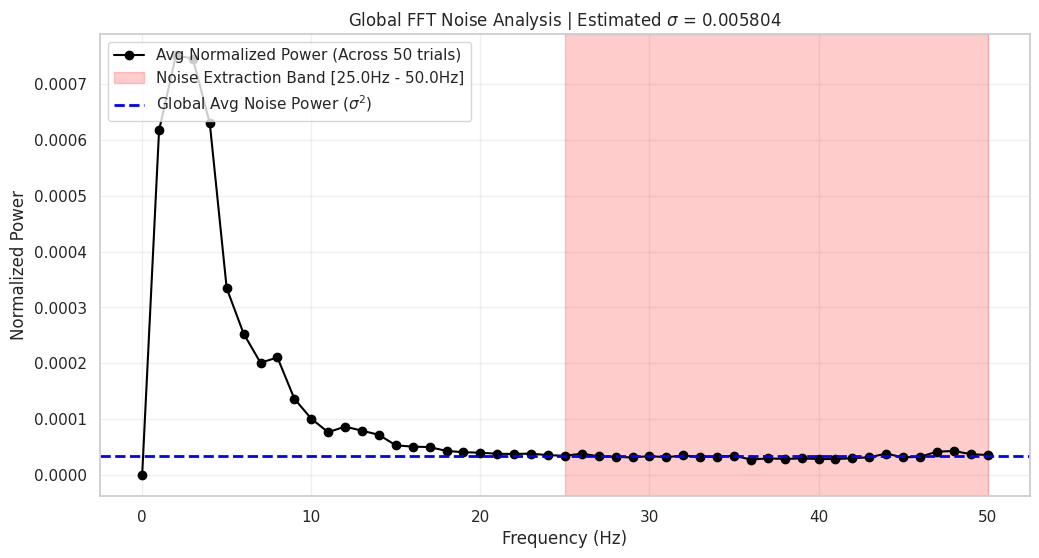

✅ Global Data-Driven Noise Std Dev (vel_noise_std): 0.005804


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def extract_global_noise_std(velocity_sequences, fs=100.0, show_plot=False):
    """
    Implements Observation Noise Modeling across MULTIPLE trials simultaneously.
    """
    # velocity_sequences shape should be (Num_Trials, Time_Steps)
    num_trials, N = velocity_sequences.shape
    
    # 1. Frequency Domain Transformation (FFT)
    # axis=1 ensures we run the FFT independently across the time steps of each trial
    fft_vals = np.fft.rfft(velocity_sequences, axis=1)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    
    # 2. Calculate Power Spectrum for EVERY trial
    power_all_trials = (np.abs(fft_vals) ** 2) / N
    
    # -> Average the power spectra across all trials to get the true underlying noise energy
    mean_power = np.mean(power_all_trials, axis=0)
    
    # 3. Normalization (Multiply by frequency f)
    norm_power = mean_power * (freqs + 1e-9)
    
    # 4. Estimate Noise Variance (Average over right half of frequency domain)
    nyquist = fs / 2.0
    lower_bound = fs / 4.0
    
    high_freq_mask = (freqs >= lower_bound) & (freqs <= nyquist)
    
    # Calculate global variance and standard deviation
    noise_variance = np.mean(norm_power[high_freq_mask])
    sigma = np.sqrt(noise_variance)
    
    # --- Visualization ---
    if show_plot:
        plt.figure(figsize=(12, 6))
        plt.plot(freqs, norm_power, marker='o', linestyle='-', color='black', label=f'Avg Normalized Power (Across {num_trials} trials)')
        plt.axvspan(lower_bound, nyquist, color='red', alpha=0.2, label=f'Noise Extraction Band [{lower_bound}Hz - {nyquist}Hz]')
        plt.axhline(noise_variance, color='blue', linestyle='--', linewidth=2, label=f'Global Avg Noise Power ($\sigma^2$)')
        
        plt.title(f"Global FFT Noise Analysis | Estimated $\sigma$ = {sigma:.6f}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Normalized Power")
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.show()
        
    return sigma

# =========================================================
# PIPELINE: LOAD MULTIPLE FOLDERS AND EXTRACT
# =========================================================

base_dir = "/home/psxkf4/panda_phypush/csv_data/"

# Define the exact folders you want to include in your noise profile.
# You can add or remove any folders from your 'ls' output here:
TARGET_FOLDERS = [
    "mgt_0.39_60_rub_w5",
    "mgt_0.48_60_rub_w5",
    "mgt_0.58_60_rub_w5",
    "mgt_0.65_60_rub_w5",
    "mgt_0.76_60_rub_w5"
]

csv_files = []
print("=== Scanning Folders ===")
for folder in TARGET_FOLDERS:
    folder_path = os.path.join(base_dir, folder)
    found_files = glob.glob(os.path.join(folder_path, "*.csv"))
    csv_files.extend(found_files)
    print(f"[{folder}]: Found {len(found_files)} CSV files.")

print(f"\nTotal CSV files to process: {len(csv_files)}")

all_real_trajectories = []
expected_length = 100 # Adjust this if your full sequence length in the CSVs is different (e.g. 100 steps)

for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)
        
        # NOTE: Make sure to target the velocity column ('v_y'). 
        # If you want to do this for acceleration later, change this to 'a_y'
        target_signal = df['v_y'].values 
        
        # Ensure all sequences are the same length so we can put them in a 2D matrix
        if len(target_signal) == expected_length:
            all_real_trajectories.append(target_signal)
        else:
            print(f"Skipping {os.path.basename(file_path)}: Length {len(target_signal)} != {expected_length}")
    except Exception as e:
        pass

# Convert list of arrays into a single 2D numpy matrix: Shape [Num_Trials, Time_Steps]
all_real_trajectories = np.array(all_real_trajectories)

print(f"Successfully loaded {all_real_trajectories.shape[0]} valid trajectories.\n")

# Extract the globally accurate noise profile
if len(all_real_trajectories) > 0:
    # Assuming your robot control loop runs at 100 Hz
    global_sigma = extract_global_noise_std(all_real_trajectories, fs=100.0, show_plot=True)
    print("="*60)
    print(f"✅ Global Data-Driven Noise Std Dev (vel_noise_std): {global_sigma:.6f}")
    print("="*60)
else:
    print("❌ No valid trajectories found. Check your file paths and expected sequence length.")

=== Loading Simulation Data ===

--- Processing: Mass 0.39 ---
✅ Found 346 matching Simulation samples.
✅ Found 10 valid Real Robot samples.

--- Processing: Mass 0.48 ---
✅ Found 405 matching Simulation samples.
✅ Found 10 valid Real Robot samples.

--- Processing: Mass 0.58 ---
✅ Found 348 matching Simulation samples.
✅ Found 10 valid Real Robot samples.

--- Processing: Mass 0.65 ---
✅ Found 339 matching Simulation samples.
✅ Found 10 valid Real Robot samples.

--- Processing: Mass 0.76 ---
✅ Found 336 matching Simulation samples.
✅ Found 10 valid Real Robot samples.

🚀 GLOBAL CALIBRATION VECTOR (60 STEPS) 🚀
Copy and paste this array into your get_estimator_input function:
calibration_offset = torch.tensor([
    0.000979, -0.000173, -0.001639, 0.001837, -0.003715, -0.007223, -0.008818, -0.009655, -0.009174, -0.009115, -0.008849, -0.008439, -0.008097, -0.007757, -0.007440, -0.007029, -0.006615, -0.006007, -0.005256, -0.004319, -0.003363, -0.002403, -0.001565, -0.000951, -0.000511, -0

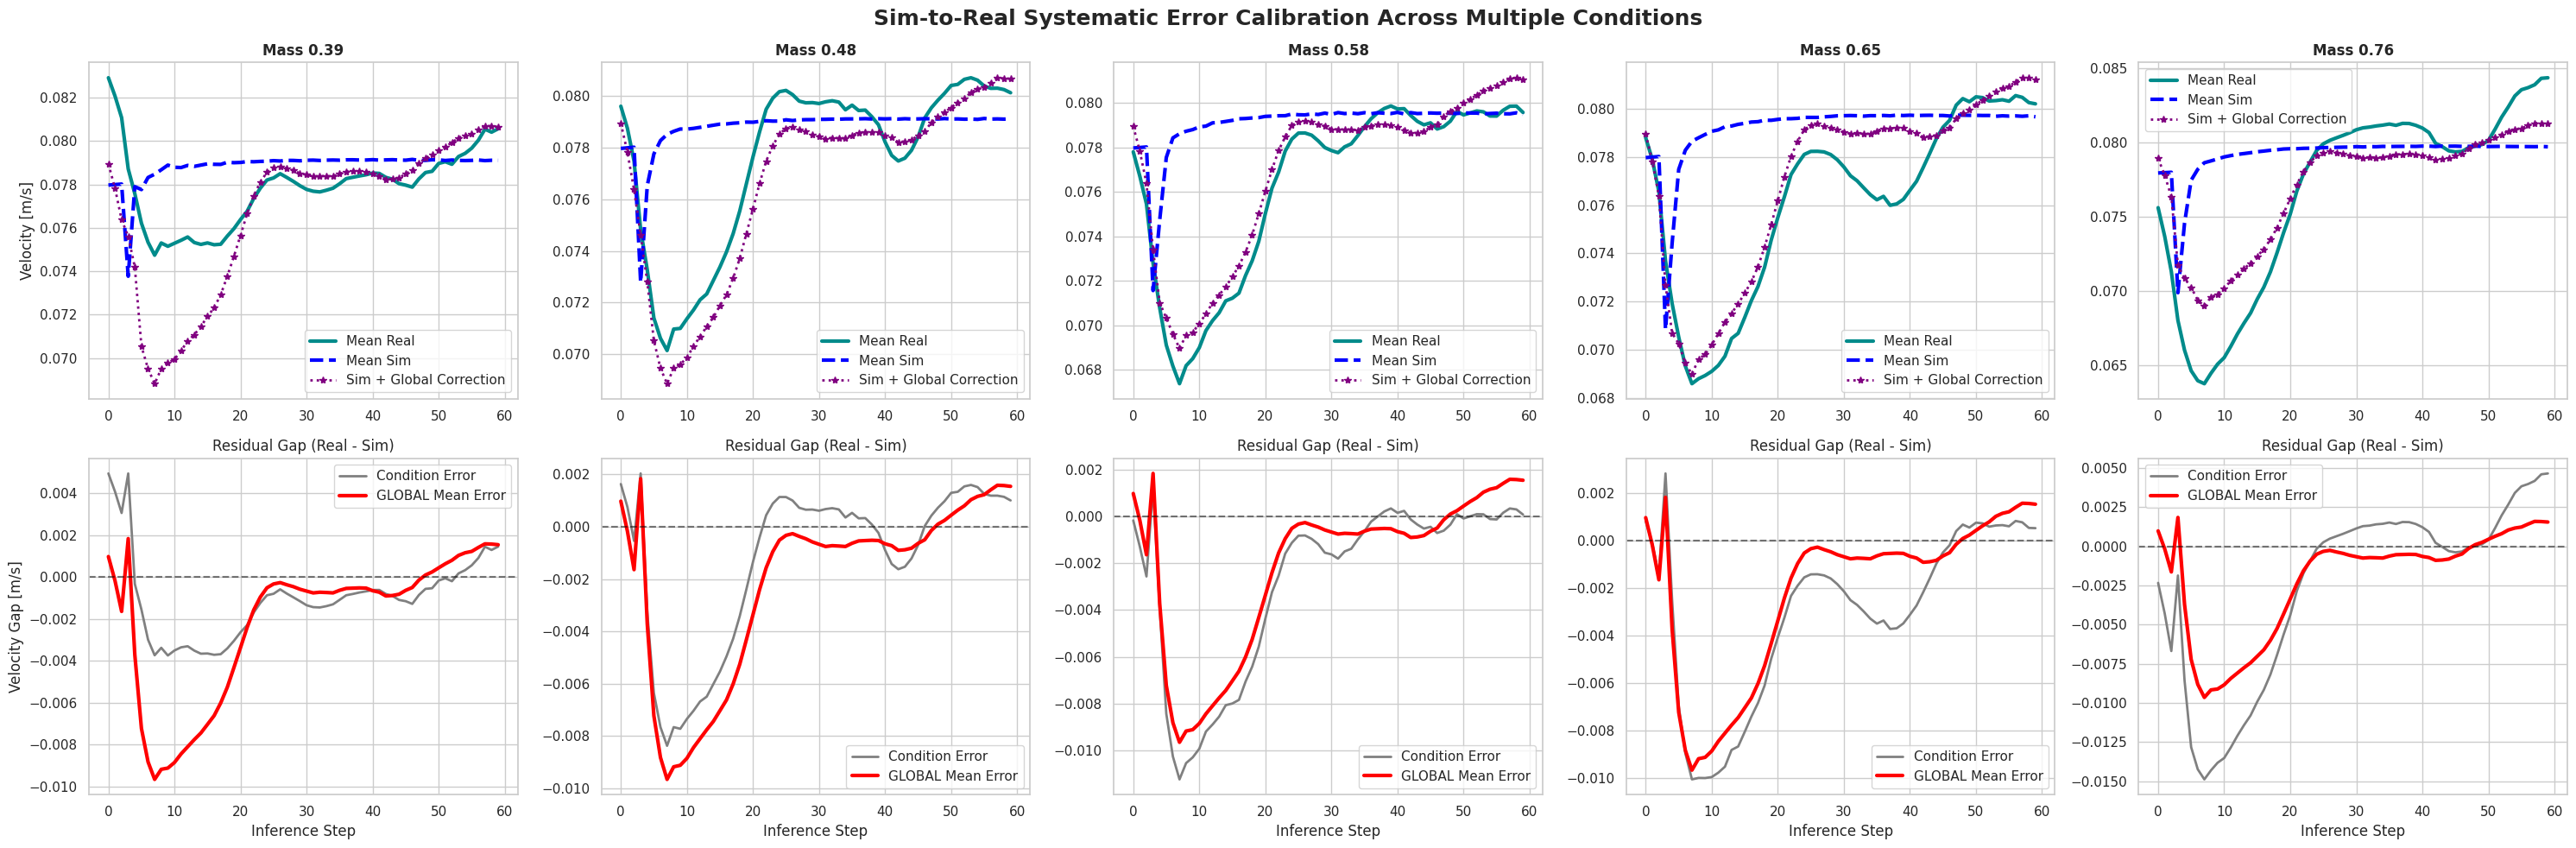

In [16]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =================================================================
# 1. CONFIGURATION
# =================================================================
# Point this to the BEST simulation CSV you found in the previous step

# First
# sim_csv_path = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0005.csv"
# Second
# sim_csv_path = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0005_CalibRubW5.csv"

# First
sim_csv_path = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0.csv"


base_real_dir = "/home/psxkf4/panda_phypush/csv_data/"

# Define your multiple conditions. 
# The script will look for simulation rows matching these targets (within a small tolerance)
# and compare them against all real CSVs in the specified folder.
CONDITIONS = [
    {"name": "Mass 0.39",  "target_m": 0.39, "target_mu": 0.3, "folder": "mgt_0.39_60_rub_w5"},
    {"name": "Mass 0.48", "target_m": 0.48, "target_mu": 0.3, "folder": "mgt_0.48_60_rub_w5"},
    {"name": "Mass 0.58", "target_m": 0.58, "target_mu": 0.3, "folder": "mgt_0.58_60_rub_w5"},
    {"name": "Mass 0.65", "target_m": 0.65, "target_mu": 0.3, "folder": "mgt_0.65_60_rub_w5"},
    {"name": "Mass 0.76",  "target_m": 0.76, "target_mu": 0.3, "folder": "mgt_0.76_60_rub_w5"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
    # {"name": "Mass 0.", "target_m": 0., "target_mu": 0.3, "folder": "mgt_"},
]


# Tolerance for finding matching simulation samples
TOLERANCE_M = 0.05
TOLERANCE_MU = 0.05

def get_flat_window(row, prefix, win_len):
    return np.array([row[f"{prefix}_{i}"] for i in range(win_len)])

# =================================================================
# 2. LOAD & GROUP DATA
# =================================================================
print("=== Loading Simulation Data ===")
sim_df = pd.read_csv(sim_csv_path)
input_cols = [c for c in sim_df.columns if "input_vel_" in c]
win_len = len(input_cols)

all_condition_errors = []  # Will store the 20-step error profile for each condition
plot_data = []             # Store data for visualization

for cond in CONDITIONS:
    print(f"\n--- Processing: {cond['name']} ---")
    
    # -------------------------------------------------------------
    # A. Get Multiple SIMULATION Samples
    # -------------------------------------------------------------
    # Filter sim dataframe for rows that match this mass and friction
    sim_mask = (np.abs(sim_df['gt_mass'] - cond['target_m']) <= TOLERANCE_M) & \
               (np.abs(sim_df['gt_mu'] - cond['target_mu']) <= TOLERANCE_MU)
    matched_sims = sim_df[sim_mask]
    
    if len(matched_sims) == 0:
        print(f"⚠️ No matching simulation samples found for Mass {cond['target_m']}, Mu {cond['target_mu']}. Skipping.")
        continue
        
    sim_trajectories = []
    for _, row in matched_sims.iterrows():
        sim_trajectories.append(get_flat_window(row, "input_vel", win_len))
    
    sim_trajectories = np.array(sim_trajectories)
    mean_sim = np.mean(sim_trajectories, axis=0)
    print(f"✅ Found {len(sim_trajectories)} matching Simulation samples.")

    # -------------------------------------------------------------
    # B. Get Multiple REAL Samples
    # -------------------------------------------------------------
    folder_path = os.path.join(base_real_dir, cond['folder'])
    real_csvs = glob.glob(os.path.join(folder_path, "*.csv"))
    
    real_trajectories = []
    for csv_file in real_csvs:
        try:
            r_df = pd.read_csv(csv_file)
            inf_idx = np.where(r_df['is_inference_region'].values == 1)[0]
            if len(inf_idx) == win_len:
                real_trajectories.append(r_df['v_y'].values[inf_idx])
        except Exception:
            pass
            
    if len(real_trajectories) == 0:
        print(f"⚠️ No valid real robot trajectories found in {cond['folder']}. Skipping.")
        continue
        
    real_trajectories = np.array(real_trajectories)
    mean_real = np.mean(real_trajectories, axis=0)
    print(f"✅ Found {len(real_trajectories)} valid Real Robot samples.")

    # -------------------------------------------------------------
    # C. Calculate Condition Error (Residual)
    # -------------------------------------------------------------
    # Error = Real Data - Simulation Data
    condition_error = mean_real - mean_sim
    all_condition_errors.append(condition_error)
    
    plot_data.append({
        "name": cond['name'],
        "mean_sim": mean_sim,
        "mean_real": mean_real,
        "error": condition_error
    })

# =================================================================
# 3. COMPUTE GLOBAL CALIBRATION VECTOR
# =================================================================
all_condition_errors = np.array(all_condition_errors)
# Average the errors across all physical conditions
global_mean_error = np.mean(all_condition_errors, axis=0)
global_std_error = np.std(all_condition_errors, axis=0)

print("\n" + "="*60)
print("🚀 GLOBAL CALIBRATION VECTOR (60 STEPS) 🚀")
print("Copy and paste this array into your get_estimator_input function:")
print("="*60)

formatted_array = ", ".join([f"{x:.6f}" for x in global_mean_error])
print(f"calibration_offset = torch.tensor([\n    {formatted_array}\n], device=extracted_vel.device, dtype=extracted_vel.dtype)")
print("="*60)

# =================================================================
# 4. VISUALIZATION
# =================================================================
num_plots = len(plot_data)
if num_plots > 0:
    fig, axes = plt.subplots(2, num_plots, figsize=(6 * num_plots, 10))
    fig.suptitle("Sim-to-Real Systematic Error Calibration Across Multiple Conditions", fontsize=18, fontweight='bold')
    
    # Handle 1D axes array if only 1 condition exists
    if num_plots == 1:
        axes = np.expand_dims(axes, axis=1)

    steps = np.arange(win_len)

    for i, p_data in enumerate(plot_data):
        # ROW 1: Mean Real vs Mean Sim
        ax1 = axes[0, i]
        ax1.plot(steps, p_data['mean_real'], color='darkcyan', linewidth=3, label='Mean Real')
        ax1.plot(steps, p_data['mean_sim'], color='blue', linewidth=3, linestyle='--', label='Mean Sim')
        
        # Plot the corrected sim to show how well the global offset fixes it
        corrected_sim = p_data['mean_sim'] + global_mean_error
        ax1.plot(steps, corrected_sim, color='purple', linewidth=2, linestyle=':', marker='*', label='Sim + Global Correction')
        
        ax1.set_title(p_data['name'], fontweight='bold')
        if i == 0: ax1.set_ylabel("Velocity [m/s]")
        ax1.legend()
        
        # ROW 2: The Error Profile
        ax2 = axes[1, i]
        ax2.plot(steps, p_data['error'], color='gray', linewidth=2, label='Condition Error')
        ax2.plot(steps, global_mean_error, color='red', linewidth=3, label='GLOBAL Mean Error')
        ax2.axhline(0, color='black', alpha=0.5, linestyle='--')
        
        ax2.set_title(f"Residual Gap (Real - Sim)")
        ax2.set_xlabel("Inference Step")
        if i == 0: ax2.set_ylabel("Velocity Gap [m/s]")
        ax2.legend()

    plt.tight_layout()
    plt.show()